# EFID

### ملخص عن شركة ايديتا وتوزعها الجغرافي ومنتجاتها ومقارنتها مع جهينه

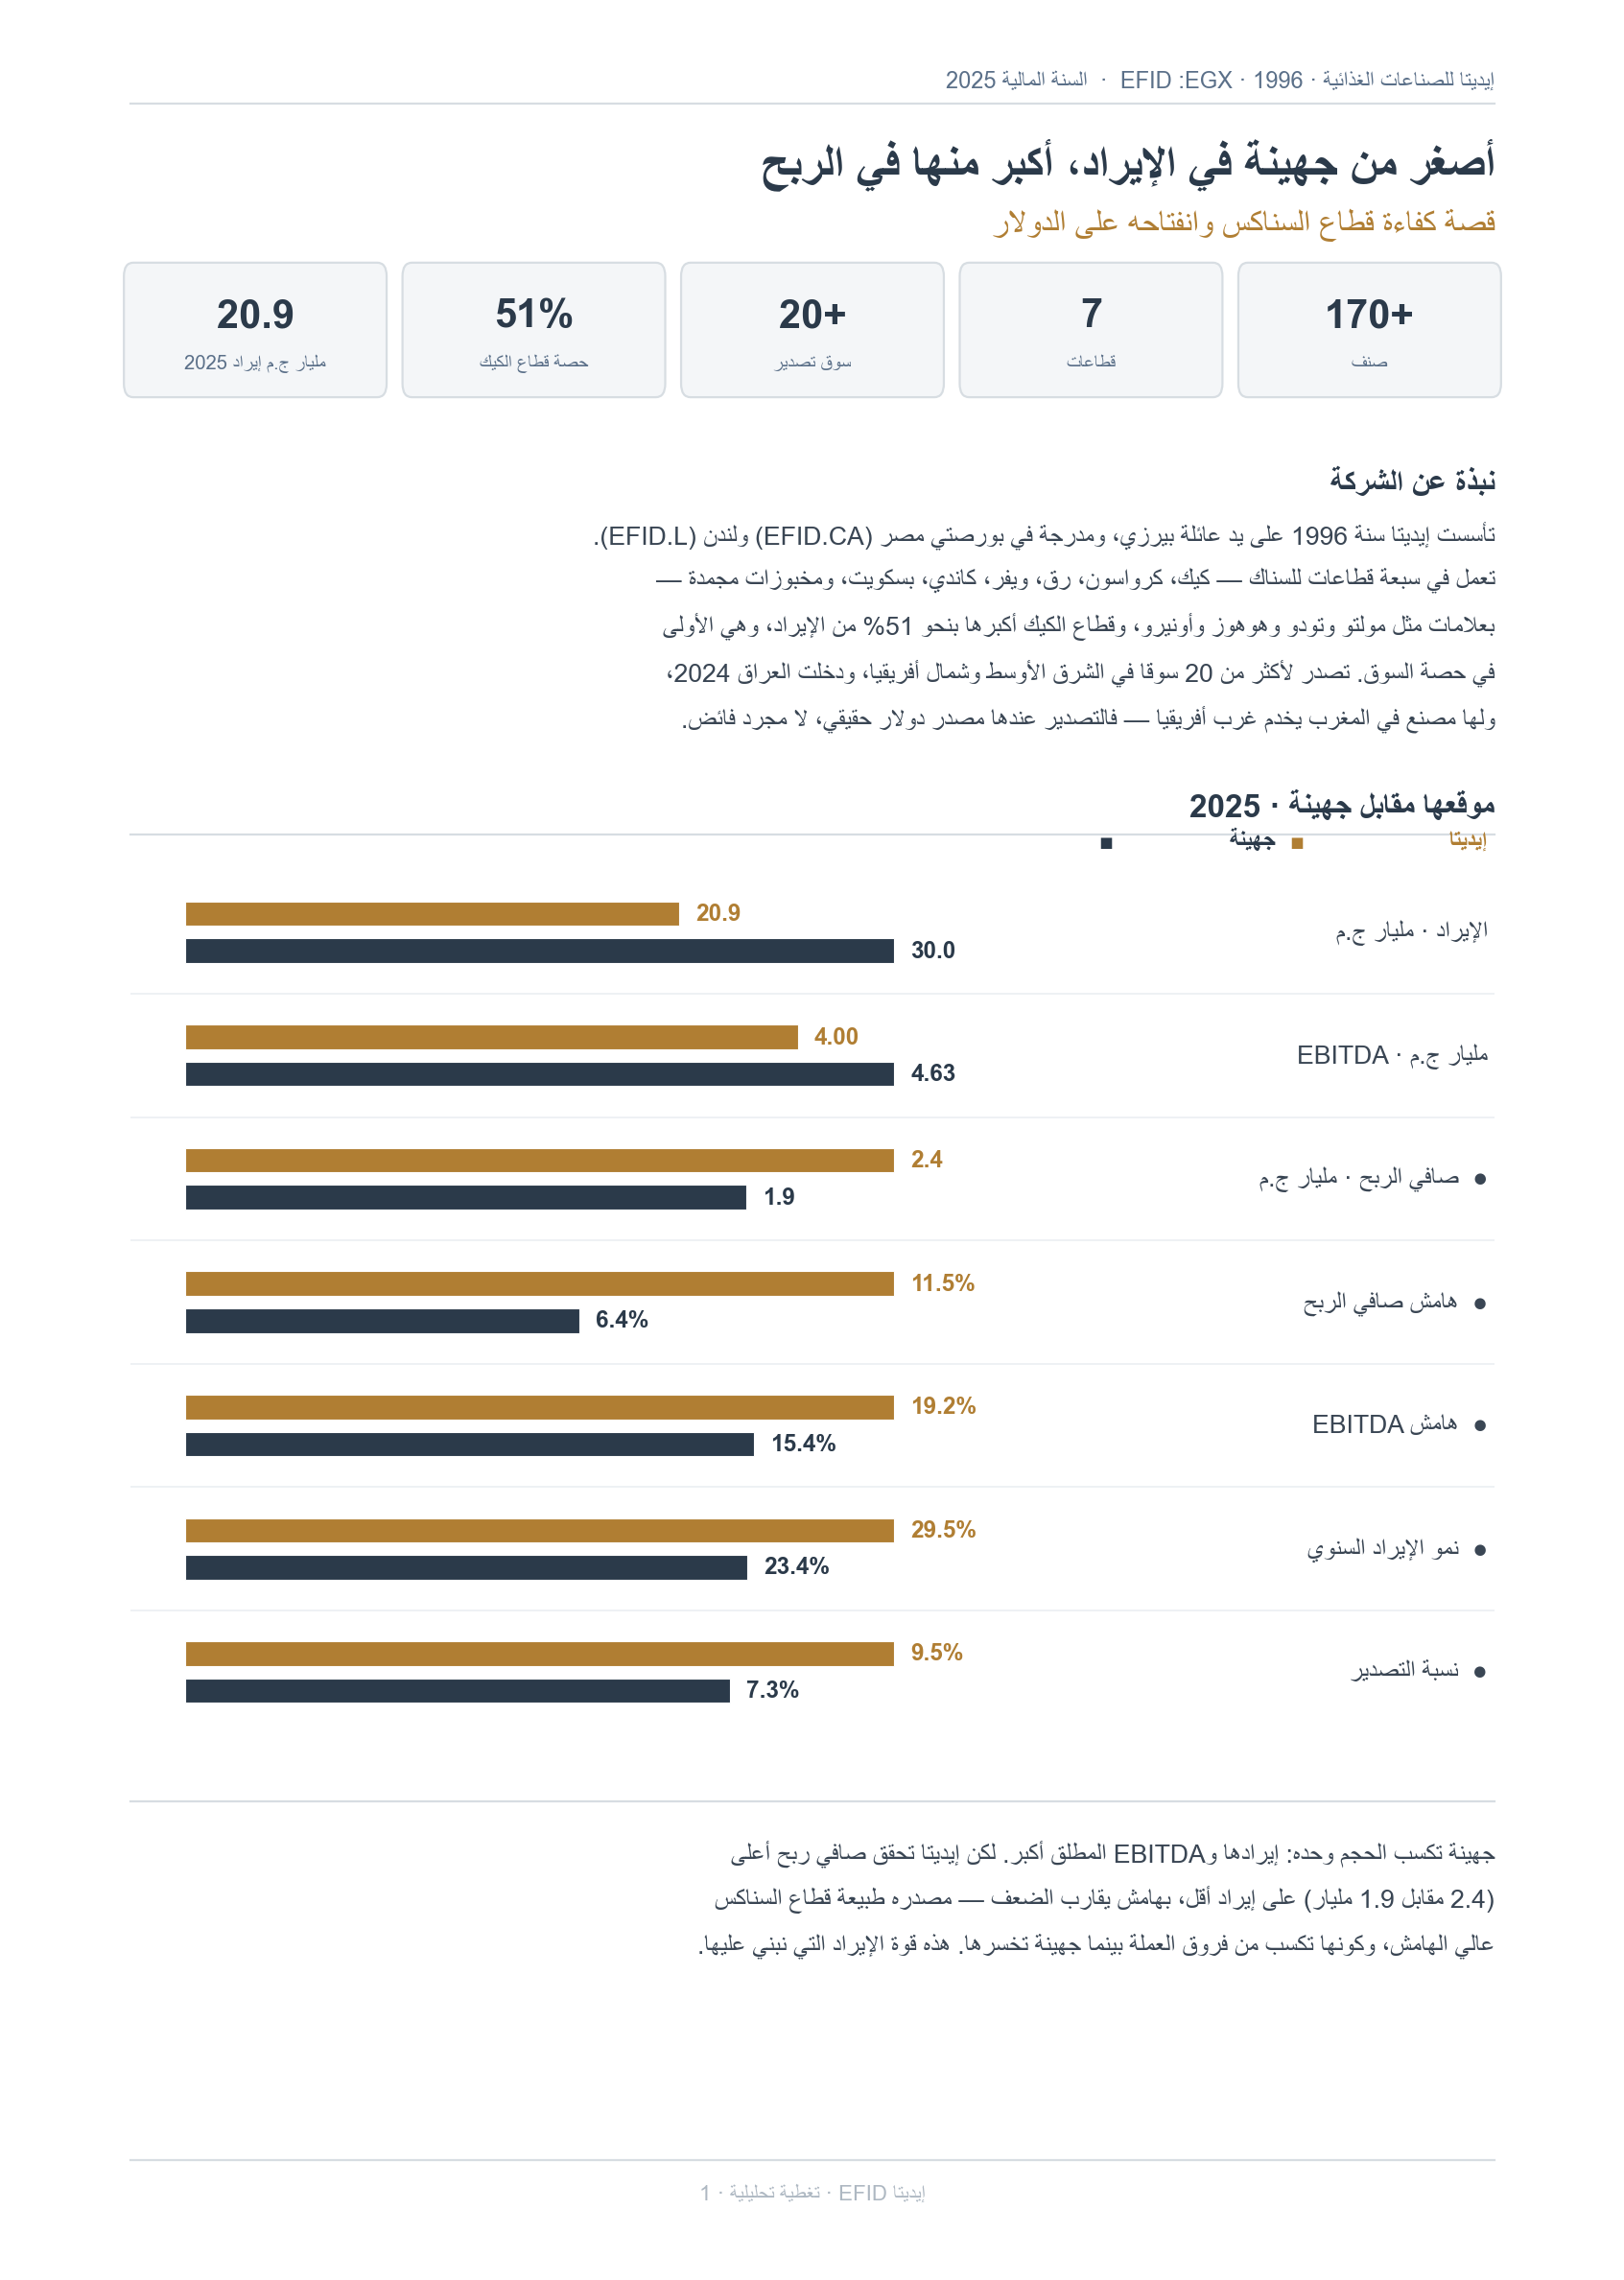

In [16]:
# -*- coding: utf-8 -*-
"""
إيديتا (EFID) · صفحة التقرير الافتتاحية (A4 رأسي)
تحاكي تقرير جهينة: لوحة SWD هادئة + لون مميز واحد، عنوان رسالة، كروت KPI، ترقيم صفحة.
المحتوى: نبذة عن إيديتا + موقعها مقابل جهينة (2025).
"""

# ===== إصلاح العربي نهائياً: تثبيت تلقائي للمكتبات لو ناقصة =====
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper", "arabic_reshaper"), ("python-bidi", "bidi")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import FancyBboxPatch, Rectangle

# ===== لوحة SWD =====
INK="#2B3A4A"; AMBER="#B07E33"; STEEL="#5B7089"; SOFT="#AEB8C2"
MIST="#EEF1F4"; CARD="#F4F6F8"; TXT="#3A4654"; LINE="#D7DDE2"

for cand in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(cand.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"]=cand; break
plt.rcParams["axes.unicode_minus"]=False

# ===== لوحة الصفحة (A4 رأسي) =====
fig = plt.figure(figsize=(8.27, 11.69), dpi=200)
fig.patch.set_facecolor("white")
ax = fig.add_axes([0,0,1,1]); ax.axis("off"); ax.set_xlim(0,1); ax.set_ylim(0,1)

L, R = 0.07, 0.93   # هوامش
def txt(x,y,s,**k): ax.text(x,y,ar(s),**k)

# --- شريط علوي ---
txt(R, 0.972, "إيديتا للصناعات الغذائية · 1996 · EFID :EGX  ·  السنة المالية 2025",
    ha="right", va="center", fontsize=8.5, color=STEEL)
ax.plot([L,R],[0.962,0.962], color=LINE, lw=0.8)

# --- عنوان رسالة ---
txt(R, 0.935, "أصغر من جهينة في الإيراد، أكبر منها في الربح",
    ha="right", va="center", fontsize=18, color=INK, weight="bold")
txt(R, 0.908, "قصة كفاءة قطاع السناكس وانفتاحه على الدولار", 
    ha="right", va="center", fontsize=12.5, color=AMBER)

# --- كروت KPI ---
cards = [("20.9","مليار ج.م إيراد 2025"),("51%","حصة قطاع الكيك"),
         ("20+","سوق تصدير"),("7","قطاعات"),("170+","صنف")]
n=len(cards); gap=0.018; cw=(R-L-gap*(n-1))/n; cy=0.835; ch=0.052
for i,(num,lab) in enumerate(cards):
    cx=L+i*(cw+gap)
    ax.add_patch(FancyBboxPatch((cx,cy),cw,ch,boxstyle="round,pad=0.004,rounding_size=0.006",
                 fc=CARD, ec=LINE, lw=0.8))
    ax.text(cx+cw/2, cy+ch*0.62, num, ha="center", va="center", fontsize=15, color=INK, weight="bold")
    ax.text(cx+cw/2, cy+ch*0.22, ar(lab), ha="center", va="center", fontsize=7.3, color=STEEL)

# --- نبذة عن الشركة ---
txt(R, 0.792, "نبذة عن الشركة", ha="right", va="center", fontsize=12, color=INK, weight="bold")
nubdha = [
 "تأسست إيديتا سنة 1996 على يد عائلة بيرزي، ومدرجة في بورصتي مصر (EFID.CA) ولندن (EFID.L).",
 "تعمل في سبعة قطاعات للسناك — كيك، كرواسون، رق، ويفر، كاندي، بسكويت، ومخبوزات مجمّدة —",
 "بعلامات مثل مولتو وتودو وهوهوز وأونيرو، وقطاع الكيك أكبرها بنحو 51% من الإيراد، وهي الأولى",
 "في حصة السوق. تصدّر لأكثر من 20 سوقاً في الشرق الأوسط وشمال أفريقيا، ودخلت العراق 2024،",
 "ولها مصنع في المغرب يخدم غرب أفريقيا — فالتصدير عندها مصدر دولار حقيقي، لا مجرد فائض.",
]
yy=0.770
for ln in nubdha:
    txt(R, yy, ln, ha="right", va="center", fontsize=9.6, color=TXT); yy-=0.0205

# --- عنوان قسم المقارنة ---
txt(R, 0.648, "موقعها مقابل جهينة · 2025", ha="right", va="center", fontsize=12, color=INK, weight="bold")
ax.plot([L,R],[0.636,0.636], color=LINE, lw=0.8)

# ===== جدول المقارنة (scorecard) داخل محور مخصص =====
axc = fig.add_axes([L, 0.235, R-L, 0.385]); axc.axis("off")
axc.set_xlim(0,1); axc.set_ylim(0,1)
# (الاسم, إيديتا, جهينة, لاحقة, خانات)
M = [("الإيراد · مليار ج.م",20.9,30.0,"",1),
     ("EBITDA · مليار ج.م",4.0,4.63,"",2),
     ("صافي الربح · مليار ج.م",2.4,1.9,"",1),
     ("هامش صافي الربح",11.5,6.4,"%",1),
     ("هامش EBITDA",19.2,15.4,"%",1),
     ("نمو الإيراد السنوي",29.5,23.4,"%",1),
     ("نسبة التصدير",9.5,7.3,"%",1)]
rows=len(M); rh=1.0/rows
track_x0, track_x1 = 0.04, 0.56   # منطقة البارّات
def fmt(v,s,d): return f"{v:.{d}f}{s}"
# مفتاح صغير أعلى الجدول
axc.text(0.995, 1.02, ar("إيديتا"), ha="right", va="bottom", fontsize=9, color=AMBER, weight="bold", transform=axc.transAxes)
axc.text(0.86, 1.02, "■", ha="right", va="bottom", fontsize=9, color=AMBER, transform=axc.transAxes)
axc.text(0.84, 1.02, ar("جهينة"), ha="right", va="bottom", fontsize=9, color=INK, weight="bold", transform=axc.transAxes)
axc.text(0.72, 1.02, "■", ha="right", va="bottom", fontsize=9, color=INK, transform=axc.transAxes)

for i,(name,ev,jv,suf,dec) in enumerate(M):
    yc = 1-(i+0.5)*rh
    vmax=max(ev,jv); bw=track_x1-track_x0
    e_len=ev/vmax*bw; j_len=jv/vmax*bw
    bh=rh*0.20
    # بار إيديتا (فوق) وجهينة (تحت)
    axc.add_patch(Rectangle((track_x0, yc+bh*0.25), e_len, bh, color=AMBER, ec="white", lw=0.4))
    axc.add_patch(Rectangle((track_x0, yc-bh*1.25), j_len, bh, color=INK,   ec="white", lw=0.4))
    axc.text(track_x0+e_len+0.012, yc+bh*0.75, fmt(ev,suf,dec), va="center", ha="left", fontsize=8.8, color=AMBER, weight="bold")
    axc.text(track_x0+j_len+0.012, yc-bh*0.75, fmt(jv,suf,dec), va="center", ha="left", fontsize=8.8, color=INK, weight="bold")
    # اسم المقياس + علامة فوز إيديتا
    star = "  ●" if ev>=jv else ""
    axc.text(0.995, yc, ar(name)+star, va="center", ha="right", fontsize=9.6, color=TXT)
    if i<rows-1:
        axc.plot([0.0,1.0],[1-(i+1)*rh]*2, color=MIST, lw=0.7)

# --- خلاصة تحليلية ---
ax.plot([L,R],[0.205,0.205], color=LINE, lw=0.8)
thesis = [
 "جهينة تكسب الحجم وحده: إيرادها وEBITDA المطلق أكبر. لكن إيديتا تحقّق صافي ربح أعلى",
 "(2.4 مقابل 1.9 مليار) على إيراد أقل، بهامش يقارب الضعف — مصدره طبيعة قطاع السناكس",
 "عالي الهامش، وكونها تكسب من فروق العملة بينما جهينة تخسرها. هذه قوة الإيراد التي نبني عليها.",
]
yy=0.182
for ln in thesis:
    txt(R, yy, ln, ha="right", va="center", fontsize=9.6, color=TXT); yy-=0.0205

# --- تذييل ---
ax.plot([L,R],[0.045,0.045], color=LINE, lw=0.8)
txt(0.5, 0.030, "إيديتا EFID · تغطية تحليلية · 1", ha="center", va="center", fontsize=8, color=SOFT)

# احفظ في فولدر مشروعك: r"C:\FMCG\EFID\edita_p1_cover.png"
plt.savefig("edita_p1_cover.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("edita_p1_cover.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## تشريح الايرادات والمنتجات

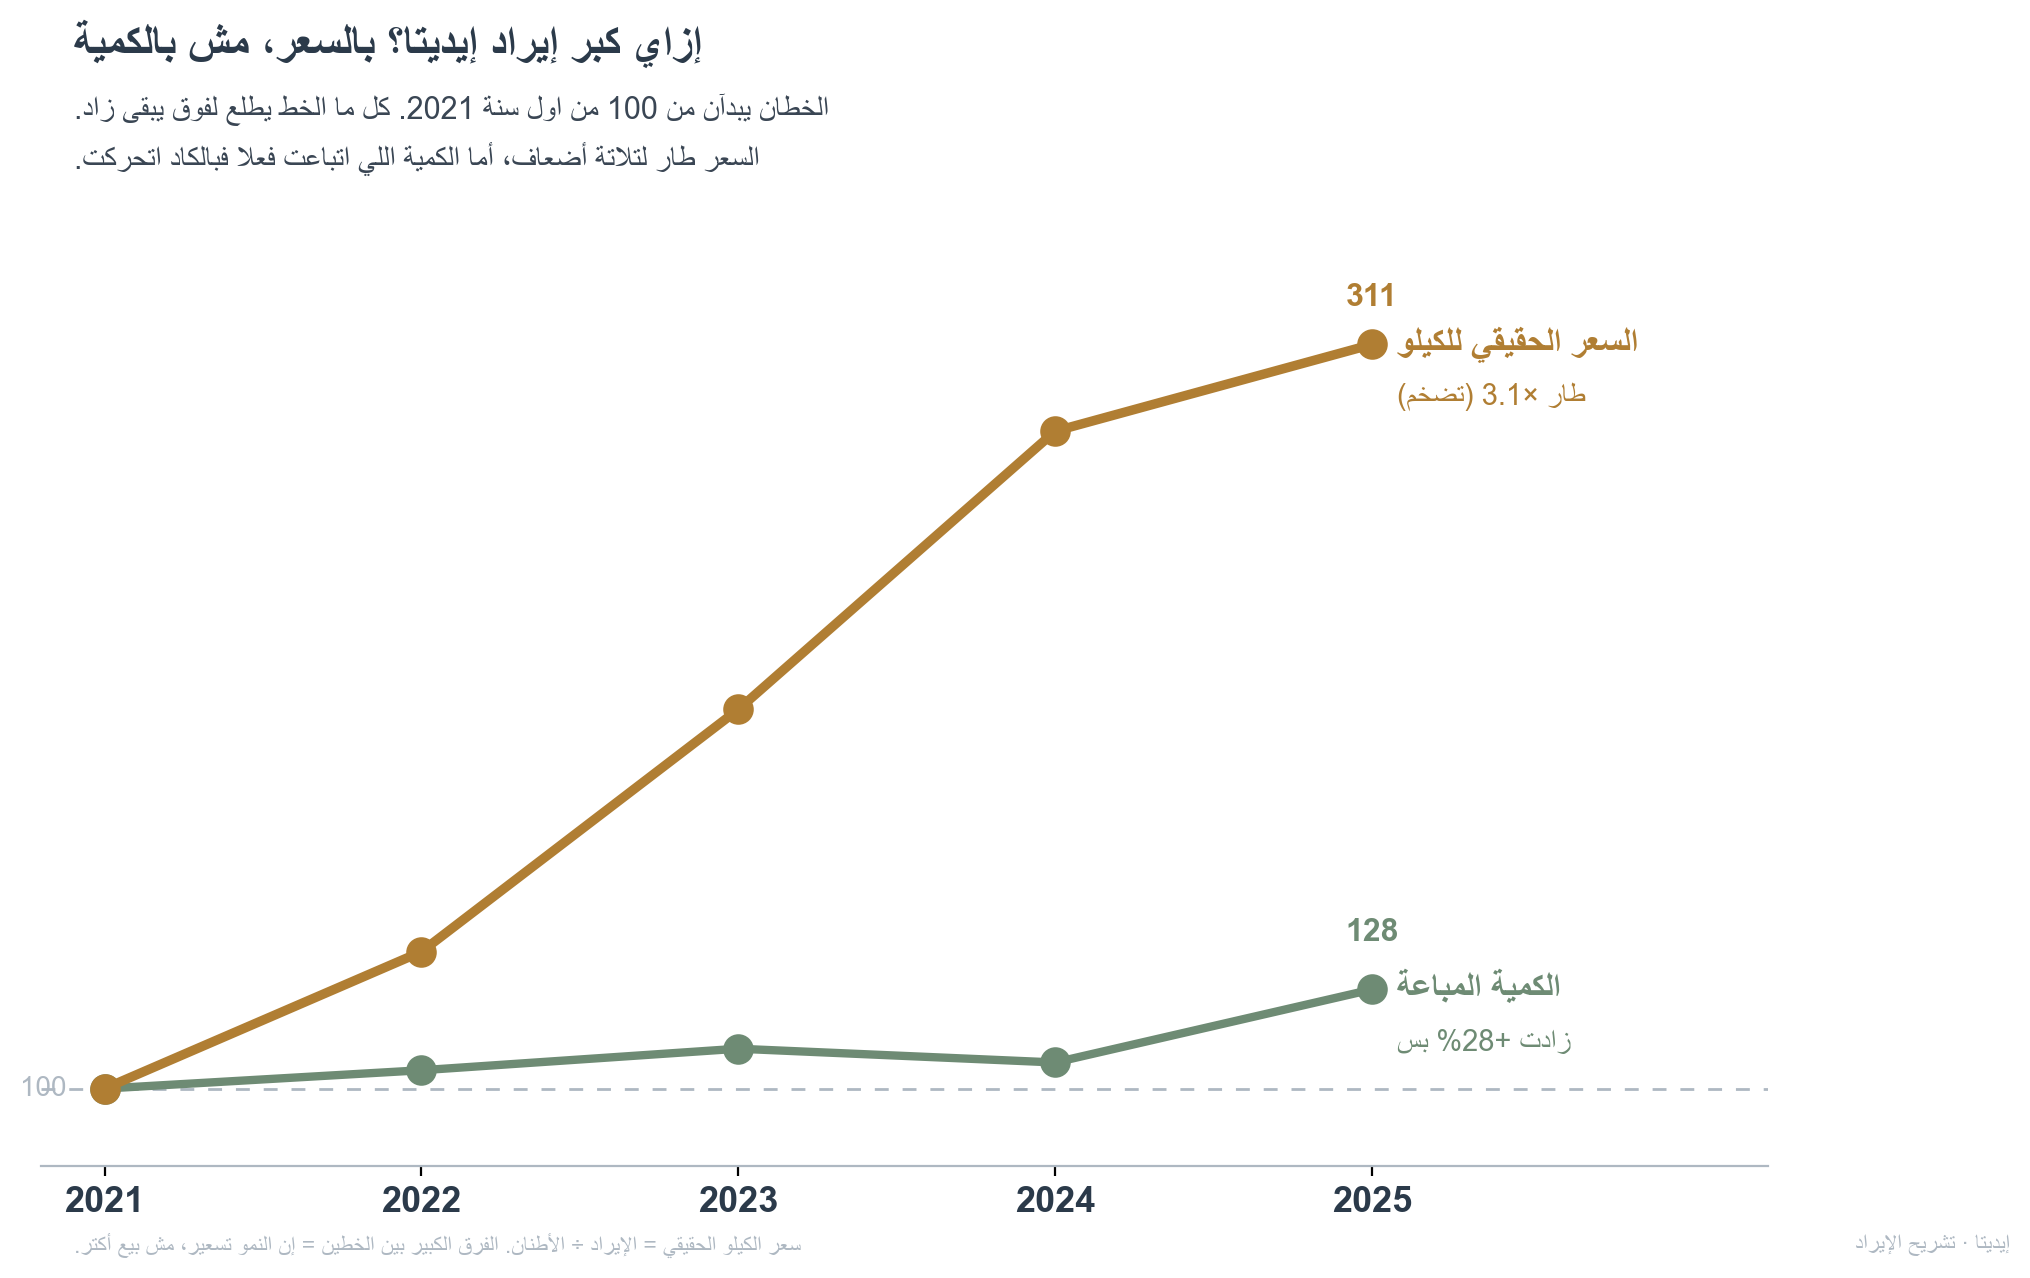

In [22]:
# -*- coding: utf-8 -*-
"""
إيديتا · رسمة افتتاحية مبسّطة جداً (ستايل STD)
خطان فقط، مفهرسان (2021 = 100):
  السعر الحقيقي للكيلو  →  طار ×3.1
  الكمية المباعة (طن)   →  +28% بس
الرسالة في جملة: الإيراد كبر بالسعر (التضخم)، مش ببيع كمية أكتر.
المصدر: تقارير نتائج إيديتا FY2021–FY2025.
"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np, matplotlib.pyplot as plt, matplotlib.font_manager as fm
INK="#2B3A4A"; AMBER="#B07E33"; SAGE="#6E8B74"; SOFT="#AEB8C2"; MIST="#EEF1F4"; TXT="#3A4654"
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"]=c; break
plt.rcParams["axes.unicode_minus"]=False

years=["2021","2022","2023","2024","2025"]; x=np.arange(len(years))
price=[100,138.8,207.5,286.4,311.0]   # سعر الكيلو الحقيقي
qty  =[100,105.2,111.3,107.4,128.1]   # الكمية بالطن

fig,ax=plt.subplots(figsize=(11,6.6),dpi=200); fig.patch.set_facecolor("white"); ax.set_facecolor("white")

# خط أساس 100
ax.axhline(100,color=SOFT,lw=1,ls=(0,(5,5)),zorder=1)
ax.text(-0.12,100,"100",fontsize=10,color=SOFT,va="center",ha="right")

# الخطان
ax.plot(x,price,color=AMBER,lw=3.4,marker="o",ms=10,zorder=4)
ax.plot(x,qty,  color=SAGE, lw=3.0,marker="o",ms=10,zorder=3)

# تسمية مباشرة في النهاية (بعيدين عن بعض → مفيش تلازق)
ax.text(4.08,311,ar("السعر الحقيقي للكيلو"),color=AMBER,fontsize=13,weight="bold",va="center")
ax.text(4.08,311-15,ar("طار ×3.1 (تضخم)"),color=AMBER,fontsize=10.5,va="center")
ax.text(4.08,128,ar("الكمية المباعة"),color=SAGE,fontsize=13,weight="bold",va="center")
ax.text(4.08,128-15,ar("زادت +28% بس"),color=SAGE,fontsize=10.5,va="center")

# قيمتا النهاية فقط (مش كل نقطة → نضافة)
ax.text(4,311+11,"311",ha="center",fontsize=11.5,color=AMBER,weight="bold")
ax.text(4,128+14,"128",ha="center",fontsize=11.5,color=SAGE,weight="bold")

ax.set_xticks(x); ax.set_xticklabels(years,fontsize=13,color=INK,weight="bold")
ax.set_xlim(-0.2,5.25); ax.set_ylim(78,340); ax.set_yticks([])
for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color(SOFT)

fig.text(0.07,0.95,ar("إزاي كبر إيراد إيديتا؟ بالسعر، مش بالكمية"),
         ha="left",va="center",fontsize=16.5,color=INK,weight="bold")
fig.text(0.07,0.90,ar("الخطّان يبدآن من 100 من اول سنة 2021. كل ما الخط يطلع لفوق يبقى زاد."),
         ha="left",va="center",fontsize=11,color=TXT)
fig.text(0.07,0.862,ar("السعر طار لتلاتة أضعاف، أما الكمية اللي اتباعت فعلاً فبالكاد اتحركت."),
         ha="left",va="center",fontsize=11,color=TXT)

fig.text(0.07,0.04,ar("سعر الكيلو الحقيقي = الإيراد ÷ الأطنان. الفرق الكبير بين الخطين = إن النمو تسعير، مش بيع أكتر."),
         ha="left",va="center",fontsize=8.3,color=SOFT)
fig.text(0.95,0.04,ar("إيديتا · تشريح الإيراد"),ha="right",va="center",fontsize=8.3,color=SOFT)

plt.subplots_adjust(left=0.055,right=0.84,top=0.80,bottom=0.10)
plt.savefig("edita_price_vs_volume_clean.png",dpi=200,bbox_inches="tight",facecolor="white")
plt.savefig("edita_price_vs_volume_clean.pdf",bbox_inches="tight",facecolor="white")
plt.show()

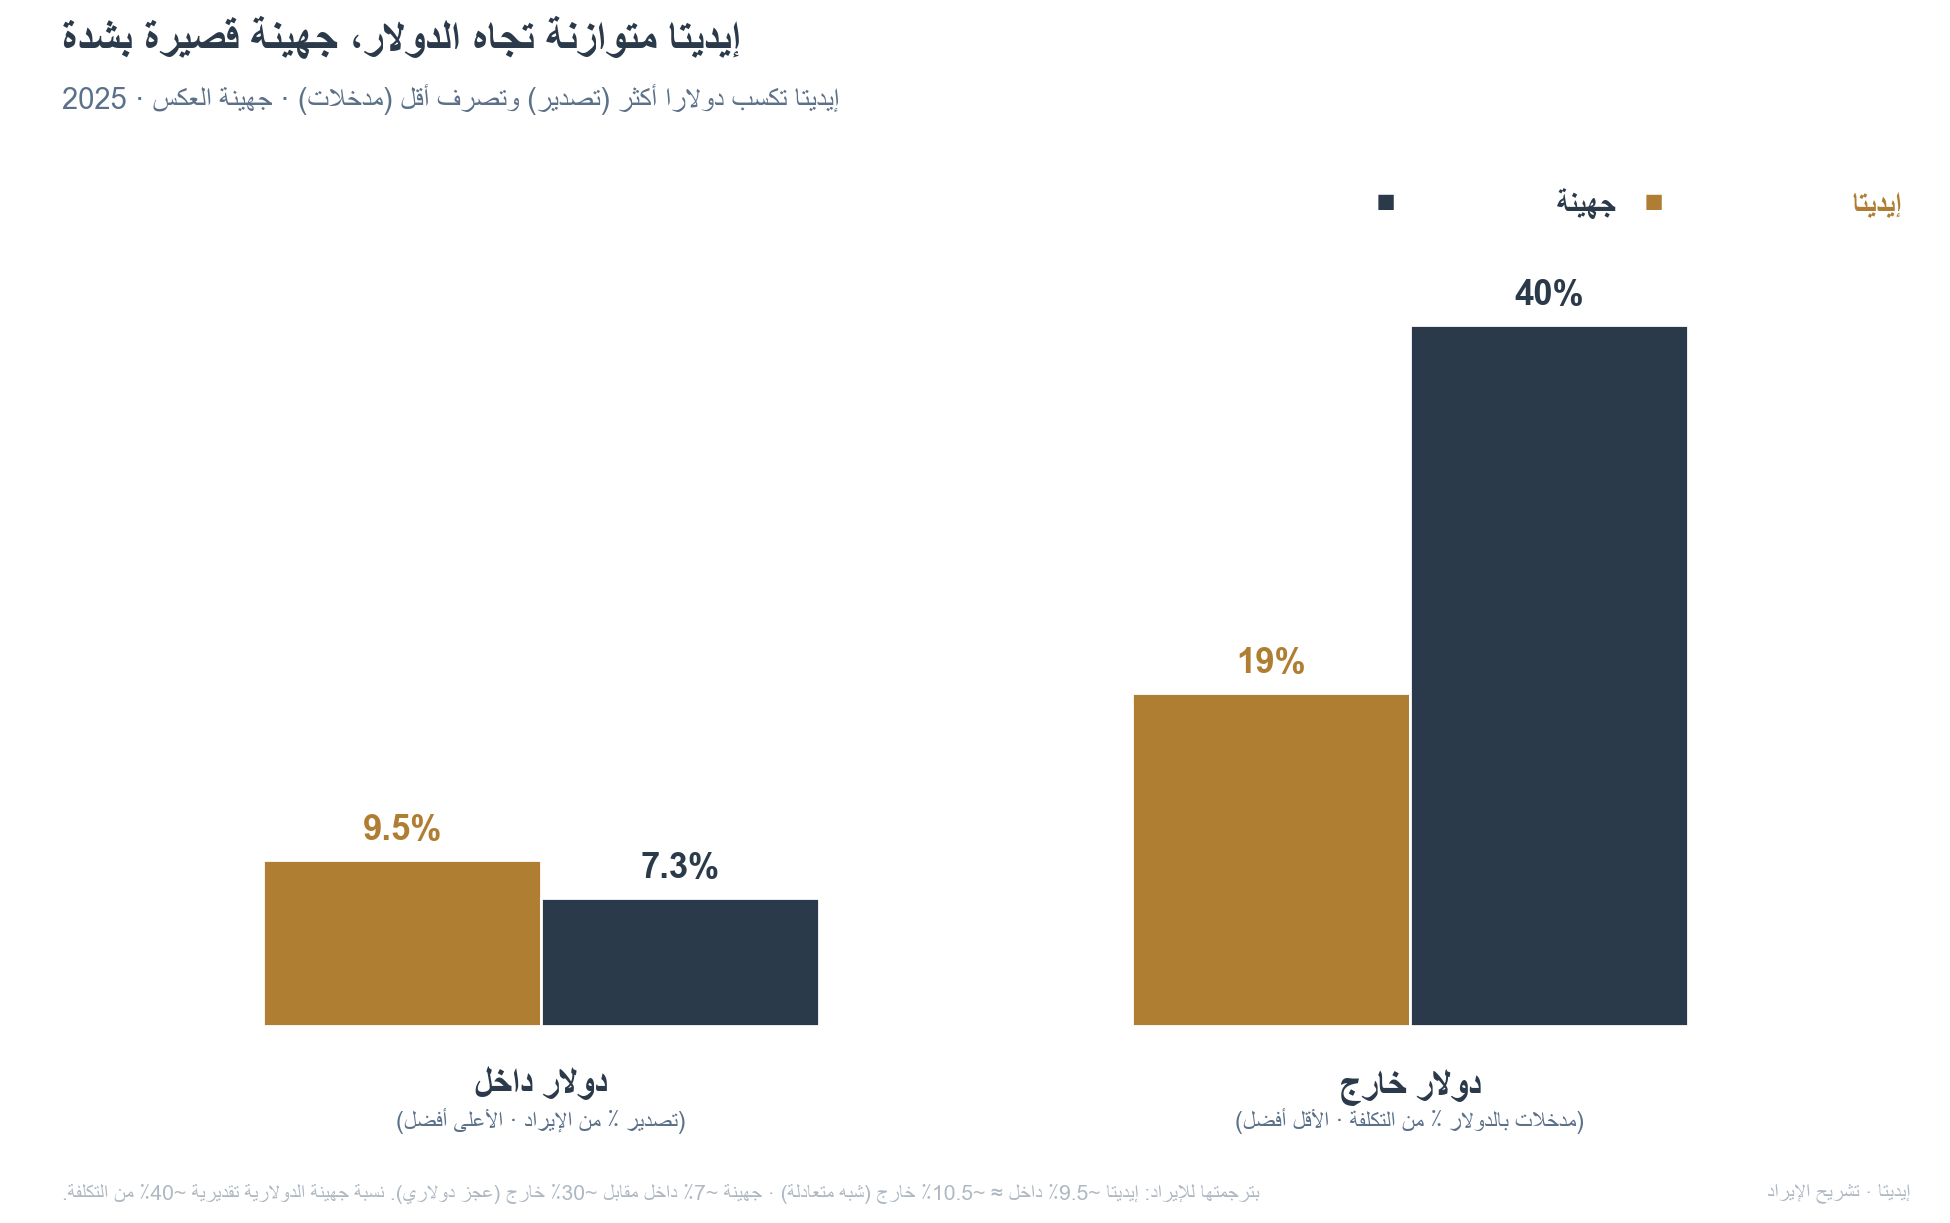

In [26]:
# -*- coding: utf-8 -*-
"""
إيديتا vs جهينة · الانكشاف على الدولار (ستايل STD نظيف)
مجموعتان: «دولار داخل» (تصدير % من الإيراد) و«دولار خارج» (مدخلات بالدولار % من التكلفة).
الرسالة: إيديتا تكسب دولار أكتر وتصرف أقل → متوازنة؛ جهينة العكس → قصيرة دولار.
المصدر: تقرير إيديتا FY2025 (تصدير 9.5%، خامات مستوردة 19%) · بيانات جهينة (تصدير 7.3%، ~40% تكلفة بالدولار).
"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np, matplotlib.pyplot as plt, matplotlib.font_manager as fm
INK="#2B3A4A"; AMBER="#B07E33"; STEEL="#5B7089"; SOFT="#AEB8C2"; SAGE="#6E8B74"; CLAY="#A8524A"; MIST="#EEF1F4"; TXT="#3A4654"
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"]=c; break
plt.rcParams["axes.unicode_minus"]=False

groups = ["دولار داخل", "دولار خارج"]
sub    = ["(تصدير ٪ من الإيراد · الأعلى أفضل)", "(مدخلات بالدولار ٪ من التكلفة · الأقل أفضل)"]
edita   = [9.5, 19.0]
juhayna = [7.3, 40.0]

x = np.arange(len(groups)); w = 0.32
fig, ax = plt.subplots(figsize=(10.5, 6.4), dpi=200); fig.patch.set_facecolor("white"); ax.set_facecolor("white")

be = ax.bar(x - w/2, edita,   w, color=AMBER, edgecolor="white", zorder=3)
bj = ax.bar(x + w/2, juhayna, w, color=INK,   edgecolor="white", zorder=3)

fmt = lambda v: f"{v:.1f}".rstrip("0").rstrip(".") + "%"
for xi,v in zip(x - w/2, edita):
    ax.text(xi, v+0.8, fmt(v), ha="center", va="bottom", fontsize=12.5, color=AMBER, weight="bold")
for xi,v in zip(x + w/2, juhayna):
    ax.text(xi, v+0.8, fmt(v), ha="center", va="bottom", fontsize=12.5, color=INK, weight="bold")

# أسماء المجموعات + الشرح الصغير
for xi,g,s in zip(x, groups, sub):
    ax.text(xi, -2.4, ar(g), ha="center", va="top", fontsize=13.5, color=INK, weight="bold")
    ax.text(xi, -4.6, ar(s), ha="center", va="top", fontsize=8.5, color=STEEL)

ax.set_xticks([]); ax.set_yticks([])
ax.set_ylim(0, 46); ax.set_xlim(-0.6, 1.6)
for sp in ax.spines.values(): sp.set_visible(False)

# مفتاح
ax.text(0.985, 1.00, ar("إيديتا"), transform=ax.transAxes, ha="right", va="bottom", fontsize=11, color=AMBER, weight="bold")
ax.text(0.86, 1.005, "■", transform=ax.transAxes, ha="right", va="bottom", fontsize=12, color=AMBER)
ax.text(0.835, 1.00, ar("جهينة"), transform=ax.transAxes, ha="right", va="bottom", fontsize=11, color=INK, weight="bold")
ax.text(0.72, 1.005, "■", transform=ax.transAxes, ha="right", va="bottom", fontsize=12, color=INK)

fig.text(0.07, 0.95, ar("إيديتا متوازنة تجاه الدولار، جهينة قصيرة بشدة"),
         ha="left", va="center", fontsize=16, color=INK, weight="bold")
fig.text(0.07, 0.905, ar("إيديتا تكسب دولاراً أكثر (تصدير) وتصرف أقل (مدخلات) · جهينة العكس · 2025"),
         ha="left", va="center", fontsize=10.5, color=STEEL)

fig.text(0.07, 0.05,
         ar("بترجمتها للإيراد: إيديتا ~9.5٪ داخل ≈ ~10.5٪ خارج (شبه متعادلة) · جهينة ~7٪ داخل مقابل ~30٪ خارج (عجز دولاري). نسبة جهينة الدولارية تقديرية ~40٪ من التكلفة."),
         ha="left", va="center", fontsize=7.6, color=SOFT)
fig.text(0.95, 0.05, ar("إيديتا · تشريح الإيراد"), ha="right", va="center", fontsize=7.6, color=SOFT)

plt.subplots_adjust(left=0.05, right=0.96, top=0.81, bottom=0.18)
plt.savefig("edita_vs_juhayna_fx.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("edita_vs_juhayna_fx.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## تشرح التكاليف

### SG&A + MOH

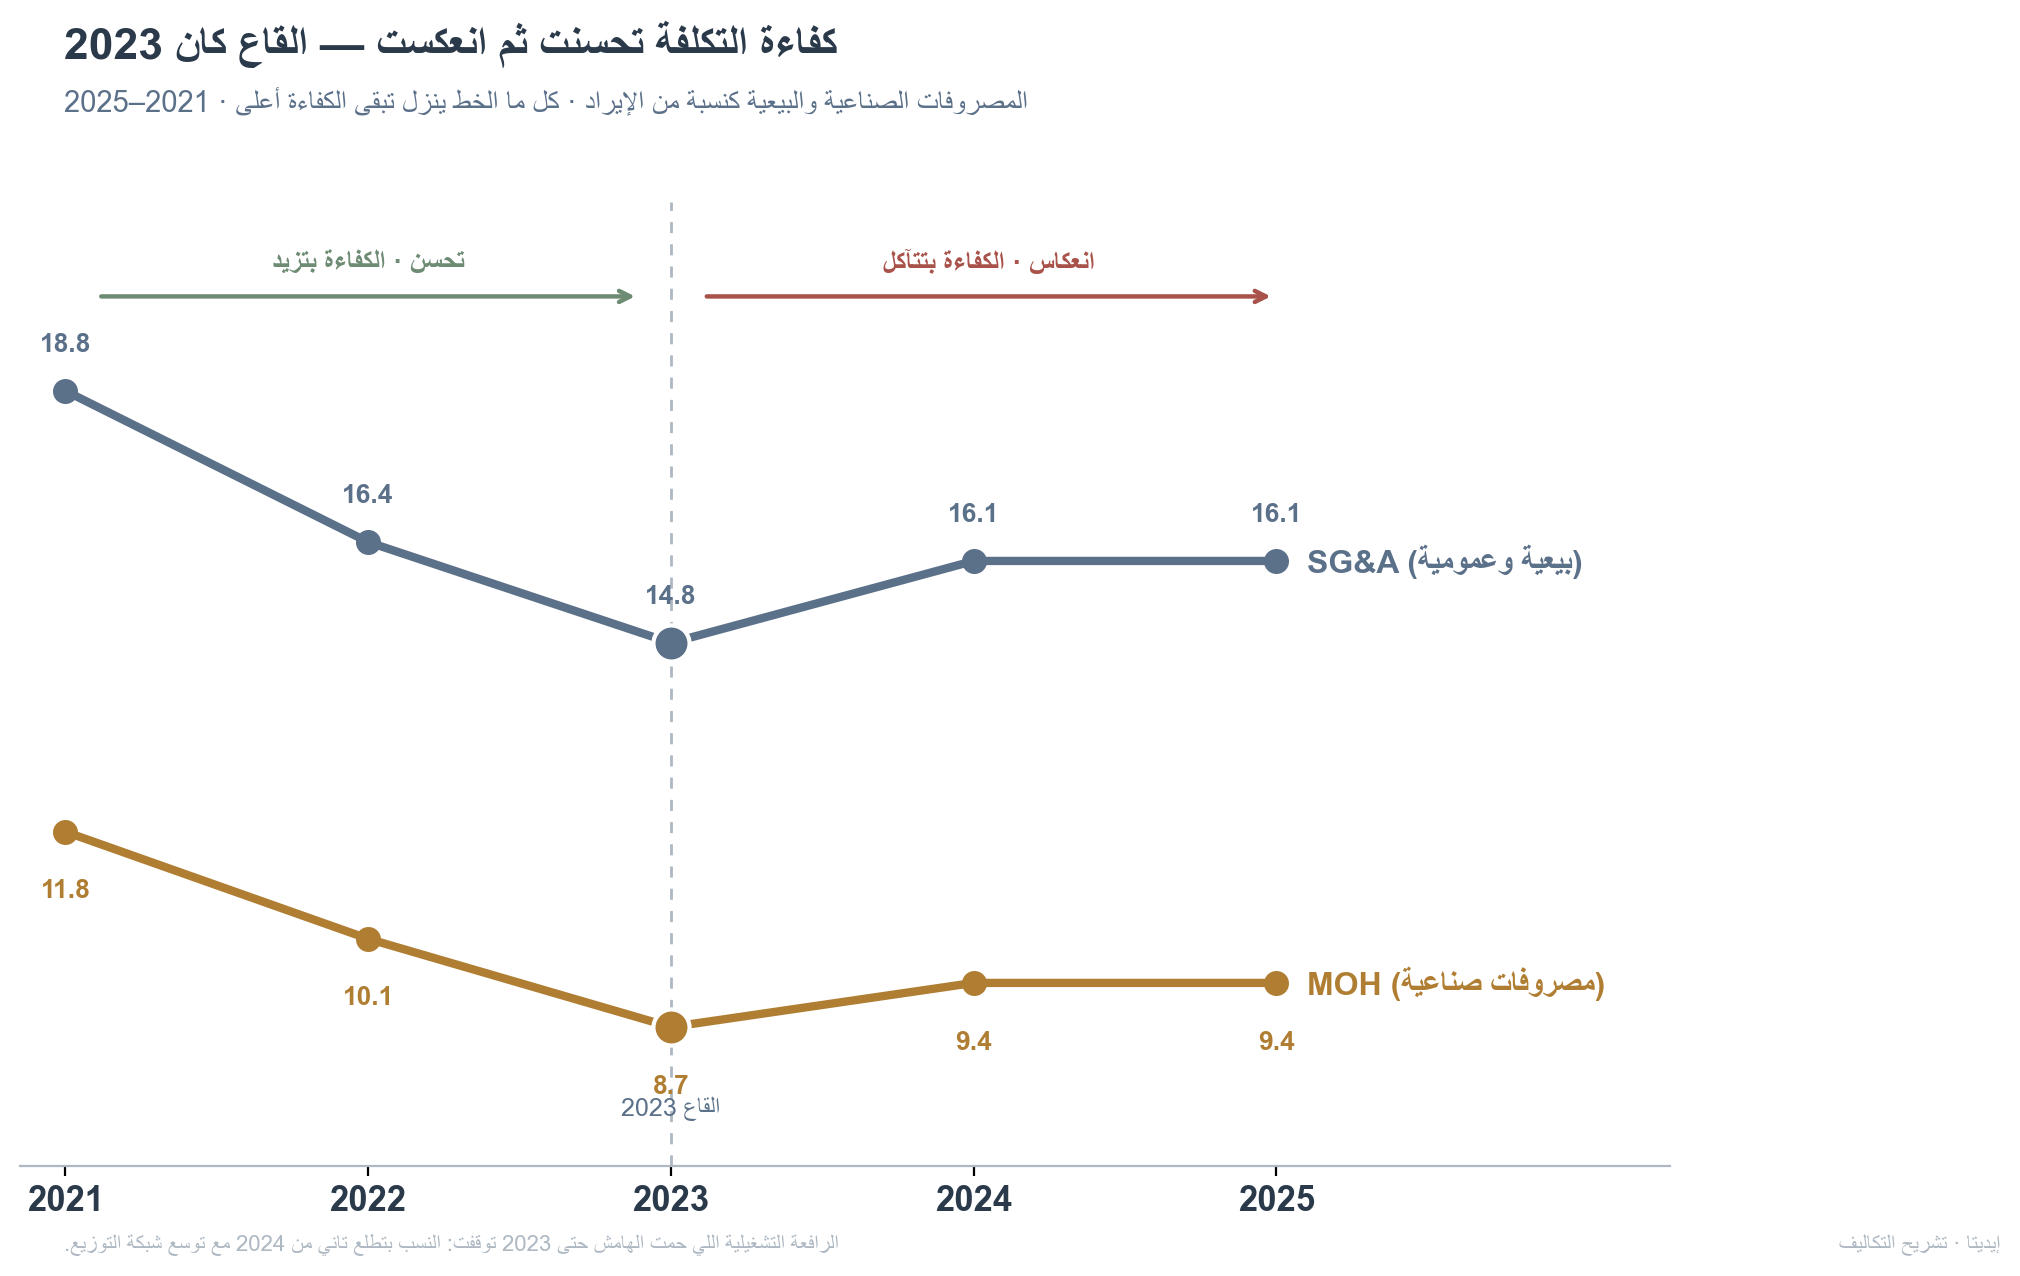

In [27]:
# -*- coding: utf-8 -*-
"""
إيديتا · اتجاه نسب التكلفة (ستايل STD)
خطّان: المصروفات الصناعية (MOH) والبيعية/العمومية (SG&A) كنسبة من الإيراد، 2021-2025.
الرسالة: الكفاءة تحسّنت حتى قاع 2023، ثم انعكست (النسب تطلع تاني) → الرافعة التشغيلية تآكلت.
المصدر: جداول التسوية EAS/IFRS في تقارير إيديتا FY2021–FY2025.
"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np, matplotlib.pyplot as plt, matplotlib.font_manager as fm
INK="#2B3A4A"; AMBER="#B07E33"; STEEL="#5B7089"; SOFT="#AEB8C2"; SAGE="#6E8B74"; CLAY="#A8524A"; MIST="#EEF1F4"; TXT="#3A4654"
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"]=c; break
plt.rcParams["axes.unicode_minus"]=False

years=["2021","2022","2023","2024","2025"]; x=np.arange(len(years))
sga=[18.8,16.4,14.8,16.1,16.1]   # بيعية وعمومية وإدارية
moh=[11.8,10.1, 8.7, 9.4, 9.4]   # مصروفات صناعية

fig,ax=plt.subplots(figsize=(11,6.6),dpi=200); fig.patch.set_facecolor("white"); ax.set_facecolor("white")

# خط رأسي خفيف عند القاع 2023
ax.axvline(2, color=SOFT, lw=1, ls=(0,(4,4)), zorder=1)

ax.plot(x,sga,color=STEEL,lw=3.0,marker="o",ms=8,zorder=3)
ax.plot(x,moh,color=AMBER,lw=3.0,marker="o",ms=8,zorder=3)
# إبراز نقطة القاع
ax.plot(2,sga[2],marker="o",ms=13,color=STEEL,zorder=4,mec="white",mew=1.5)
ax.plot(2,moh[2],marker="o",ms=13,color=AMBER,zorder=4,mec="white",mew=1.5)

# قيم عند كل نقطة
for xi,v in zip(x,sga): ax.text(xi,v+0.55,f"{v:.1f}",ha="center",va="bottom",fontsize=9.5,color=STEEL,weight="bold")
for xi,v in zip(x,moh): ax.text(xi,v-0.75,f"{v:.1f}",ha="center",va="top",fontsize=9.5,color=AMBER,weight="bold")

# تسمية مباشرة في النهاية
ax.text(4.1,16.1,ar("SG&A (بيعية وعمومية)"),color=STEEL,fontsize=11.5,weight="bold",va="center")
ax.text(4.1,9.4, ar("MOH (مصروفات صناعية)"),color=AMBER,fontsize=11.5,weight="bold",va="center")

# شرح المرحلتين
ax.annotate("", xy=(1.9,20.3), xytext=(0.1,20.3), arrowprops=dict(arrowstyle="->",color=SAGE,lw=1.6))
ax.text(1.0,20.7,ar("تحسّن · الكفاءة بتزيد"),ha="center",fontsize=10,color=SAGE,weight="bold")
ax.annotate("", xy=(4.0,20.3), xytext=(2.1,20.3), arrowprops=dict(arrowstyle="->",color=CLAY,lw=1.6))
ax.text(3.05,20.7,ar("انعكاس · الكفاءة بتتآكل"),ha="center",fontsize=10,color=CLAY,weight="bold")
ax.text(2,7.3,ar("القاع 2023"),ha="center",fontsize=9,color=STEEL)

ax.set_xticks(x); ax.set_xticklabels(years,fontsize=12.5,color=INK,weight="bold")
ax.set_xlim(-0.15,5.3); ax.set_ylim(6.5,21.8); ax.set_yticks([])
for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color(SOFT)

fig.text(0.07,0.95,ar("كفاءة التكلفة تحسّنت ثم انعكست — القاع كان 2023"),
         ha="left",va="center",fontsize=16,color=INK,weight="bold")
fig.text(0.07,0.905,ar("المصروفات الصناعية والبيعية كنسبة من الإيراد · كل ما الخط ينزل تبقى الكفاءة أعلى · 2021–2025"),
         ha="left",va="center",fontsize=10.5,color=STEEL)
fig.text(0.07,0.04,ar("الرافعة التشغيلية اللي حمَت الهامش حتى 2023 توقّفت: النسب بتطلع تاني من 2024 مع توسّع شبكة التوزيع."),
         ha="left",va="center",fontsize=8,color=SOFT)
fig.text(0.95,0.04,ar("إيديتا · تشريح التكاليف"),ha="right",va="center",fontsize=8,color=SOFT)

plt.subplots_adjust(left=0.05,right=0.80,top=0.83,bottom=0.10)
plt.savefig("edita_cost_ratios_trend.png",dpi=200,bbox_inches="tight",facecolor="white")
plt.savefig("edita_cost_ratios_trend.pdf",bbox_inches="tight",facecolor="white")
plt.show()

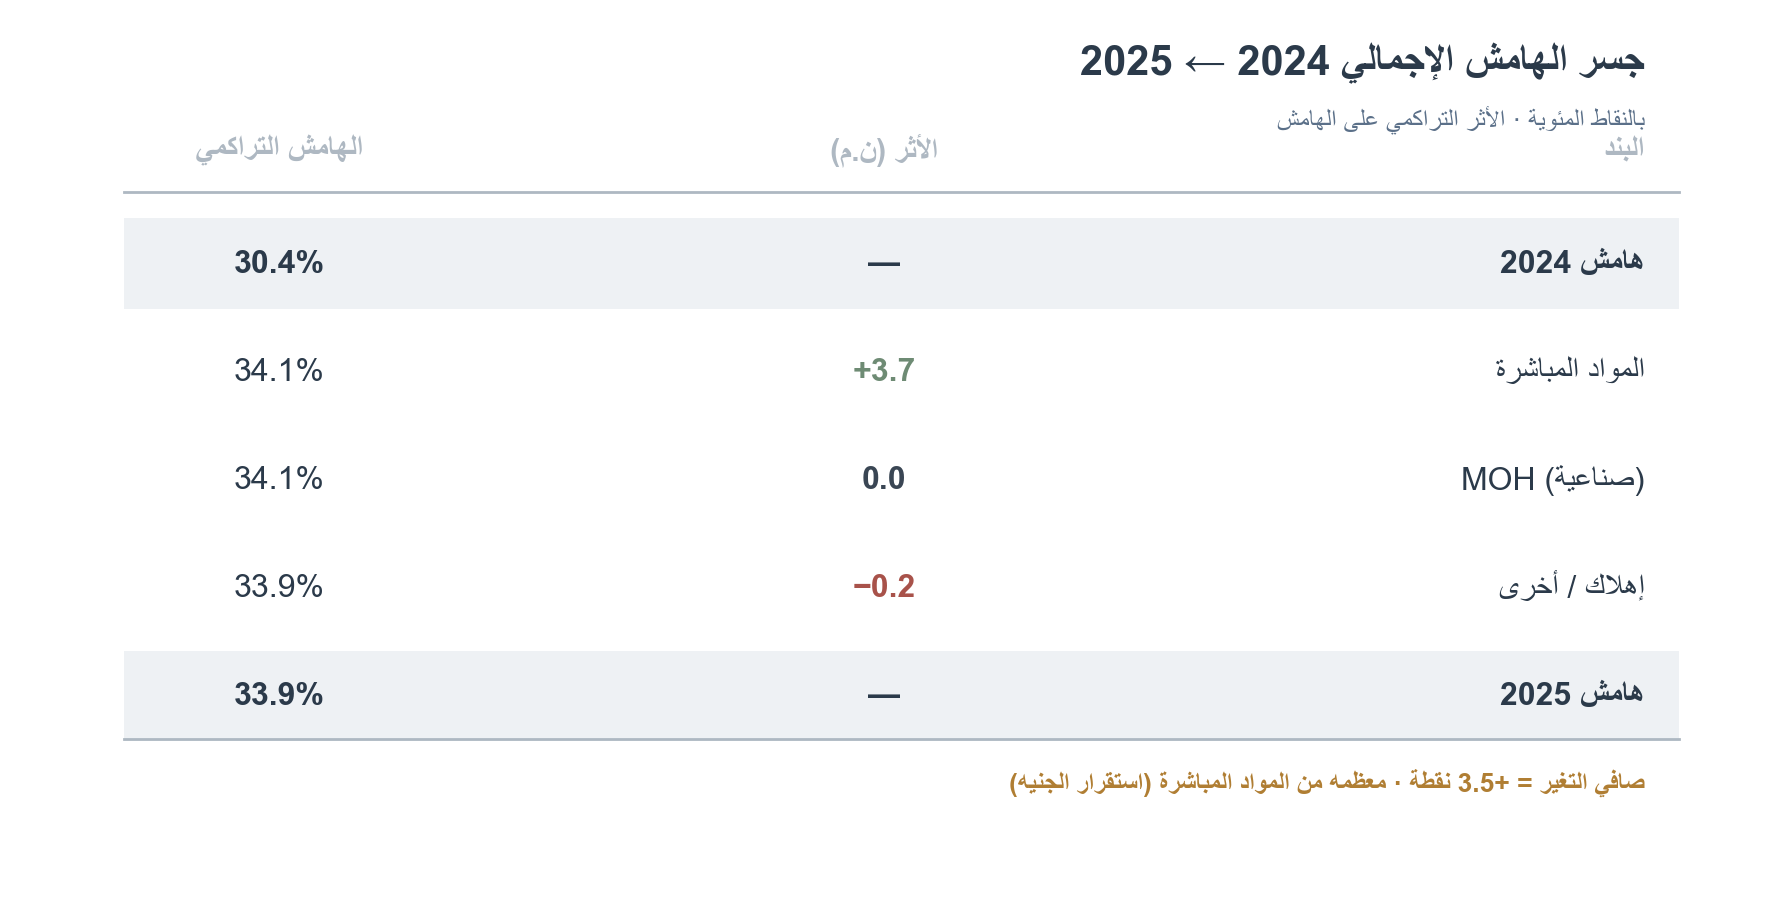

In [29]:
# -*- coding: utf-8 -*-
"""جدول جسر الهامش الإجمالي لإيديتا 2024 → 2025 (ستايل STD)"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper", "arabic_reshaper"), ("python-bidi", "bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
INK="#2B3A4A"; AMBER="#B07E33"; STEEL="#5B7089"; SOFT="#AEB8C2"
SAGE="#6E8B74"; CLAY="#A8524A"; MIST="#EEF1F4"; TXT="#3A4654"
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"]=c; break
plt.rcParams["axes.unicode_minus"]=False

# (البند، الأثر بالنقطة المئوية، الهامش التراكمي، النوع)
rows = [
    ("هامش 2024",       "—",     "30.4%", "anchor"),
    ("المواد المباشرة", "+3.7",  "34.1%", "up"),
    ("MOH (صناعية)",    "0.0",   "34.1%", "flat"),
    ("إهلاك / أخرى",    "\u22120.2", "33.9%", "down"),
    ("هامش 2025",       "—",     "33.9%", "anchor"),
]
dcol = {"up": SAGE, "down": CLAY, "flat": TXT, "anchor": INK}

fig, ax = plt.subplots(figsize=(9, 4.6), dpi=200)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

x_label, x_delta, x_cum = 0.94, 0.50, 0.15   # RTL: البند يمين، القيم يسار
top, rowh, n = 0.78, 0.125, len(rows)

ax.text(0.94, 0.95, ar("جسر الهامش الإجمالي 2024 \u2190 2025"),
        ha="right", va="center", fontsize=15, color=INK, weight="bold")
ax.text(0.94, 0.885, ar("بالنقاط المئوية \u00b7 الأثر التراكمي على الهامش"),
        ha="right", va="center", fontsize=9.5, color=STEEL)

# رؤوس الأعمدة
yh = top + rowh*0.55
ax.text(x_label, yh, ar("البند"), ha="right", va="center", fontsize=11, color=SOFT, weight="bold")
ax.text(x_delta, yh, ar("الأثر (ن.م)"), ha="center", va="center", fontsize=11, color=SOFT, weight="bold")
ax.text(x_cum,   yh, ar("الهامش التراكمي"), ha="center", va="center", fontsize=11, color=SOFT, weight="bold")
ax.plot([0.06, 0.96], [top+rowh*0.16]*2, color=SOFT, lw=1)

# الصفوف
for i, (lbl, delta, cum, kind) in enumerate(rows):
    y = top - rowh*(i+0.5)
    if kind == "anchor":   # تظليل صفّي البداية والنهاية
        ax.add_patch(Rectangle((0.06, y-rowh*0.42), 0.90, rowh*0.84,
                               facecolor=MIST, edgecolor="none", zorder=1))
    bold = "bold" if kind == "anchor" else "normal"
    ax.text(x_label, y, ar(lbl), ha="right",  va="center", fontsize=11.5, color=INK, weight=bold, zorder=2)
    ax.text(x_delta, y, delta,   ha="center", va="center", fontsize=11.5, color=dcol[kind], weight="bold", zorder=2)
    ax.text(x_cum,   y, cum,     ha="center", va="center", fontsize=11.5, color=INK, weight=bold, zorder=2)

# سطر الصافي
ynet = top - rowh*n - rowh*0.30
ax.plot([0.06, 0.96], [ynet+rowh*0.40]*2, color=SOFT, lw=1)
ax.text(0.94, ynet, ar("صافي التغيّر = +3.5 نقطة \u00b7 معظمه من المواد المباشرة (استقرار الجنيه)"),
        ha="right", va="center", fontsize=9.5, color=AMBER, weight="bold")

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.04)
plt.savefig("edita_gm_bridge_table.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("edita_gm_bridge_table.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## نبدأ نشوف فروق العمله ومقارنه بسيطه بينها وبين جهينه

C:\Users\dawod\AppData\Local\Temp\ipykernel_46748\4294116647.py:73: UserWarning: Glyph 9640 (\N{SQUARE WITH UPPER RIGHT TO LOWER LEFT FILL}) missing from font(s) Arial.
  plt.savefig("edita_vs_juhayna_fx_full.png",dpi=200,bbox_inches="tight",facecolor="white")
C:\Users\dawod\AppData\Local\Temp\ipykernel_46748\4294116647.py:74: UserWarning: Glyph 9640 (\N{SQUARE WITH UPPER RIGHT TO LOWER LEFT FILL}) missing from font(s) Arial.
  plt.savefig("edita_vs_juhayna_fx_full.pdf",bbox_inches="tight",facecolor="white")
C:\Users\dawod\AppData\Local\Temp\ipykernel_46748\4294116647.py:74: UserWarning: Glyph 9640 (\N{SQUARE WITH UPPER RIGHT TO LOWER LEFT FILL}) missing from font(s) Arial.
  plt.savefig("edita_vs_juhayna_fx_full.pdf",bbox_inches="tight",facecolor="white")
C:\Users\dawod\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9640 (\N{SQUARE WITH UPPER RIGHT TO LOWER LEFT FILL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **

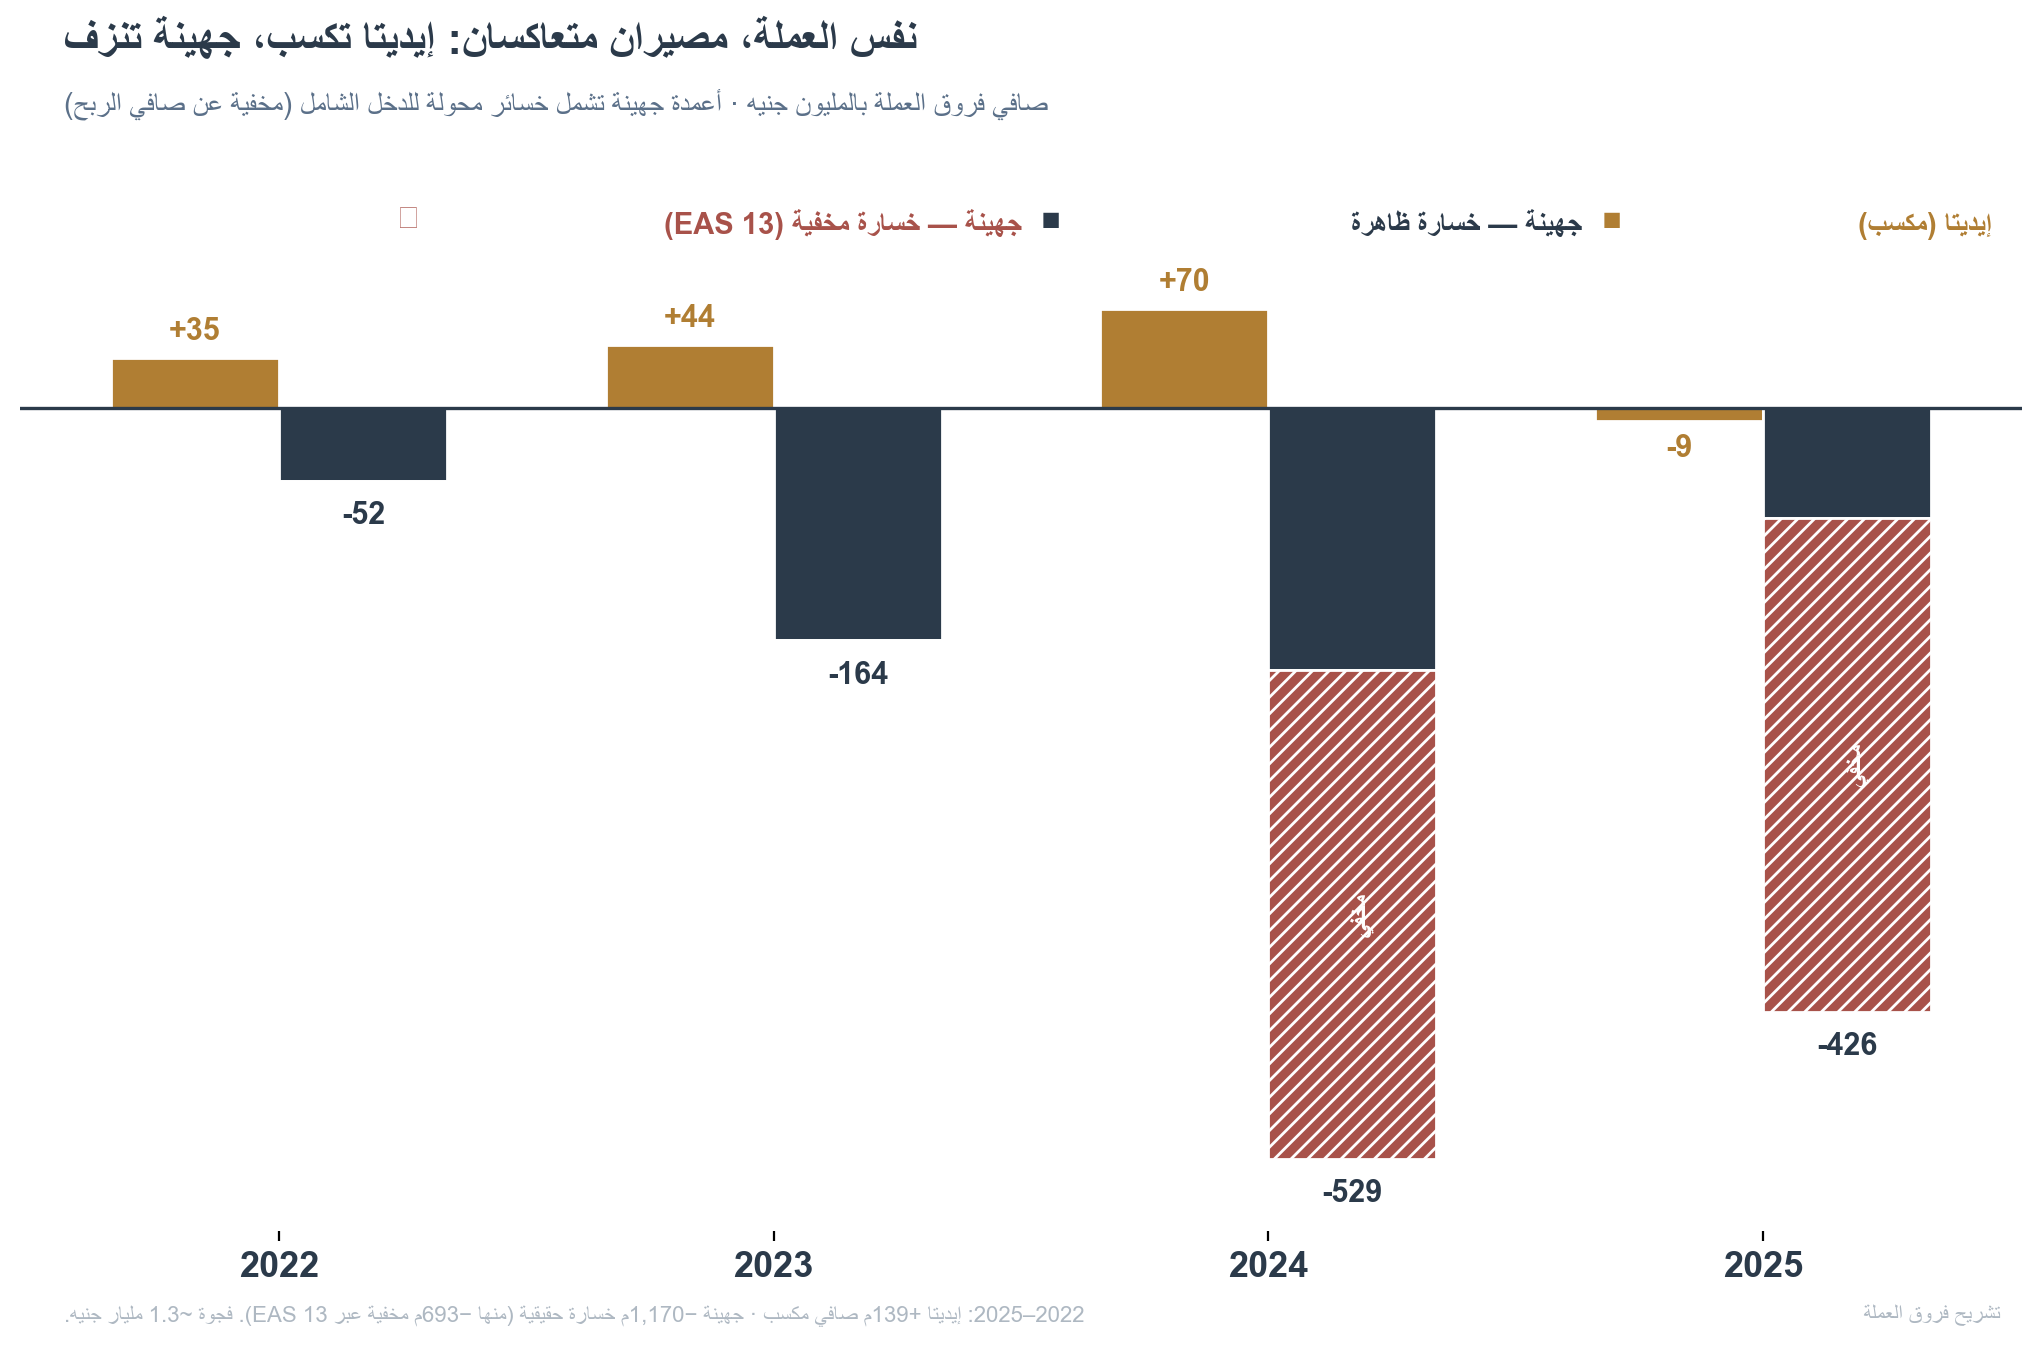

In [30]:
# -*- coding: utf-8 -*-
"""
إيديتا vs جهينة · صافي فروق العملة 2022-2025 (ستايل STD)
أعمدة متعاكسة: إيديتا تكسب (فوق الصفر)، جهينة تنزف (تحت)، مع إظهار الجزء المخفي في OCI عبر EAS 13.
المصدر: موديل إيديتا (سطر FX في قائمة الدخل) · قاعدة بيانات جهينة (شيت فروق العملة).
"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np, matplotlib.pyplot as plt, matplotlib.font_manager as fm
INK="#2B3A4A"; AMBER="#B07E33"; STEEL="#5B7089"; SOFT="#AEB8C2"; SAGE="#6E8B74"; CLAY="#A8524A"; MIST="#EEF1F4"; TXT="#3A4654"
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"]=c; break
plt.rcParams["axes.unicode_minus"]=False

years=["2022","2023","2024","2025"]; x=np.arange(len(years)); w=0.34
edita     =[ 35.0,  44.1,  69.7,  -9.4]
juh_vis   =[-51.5,-163.8,-184.5, -77.5]   # خسارة ظاهرة في قائمة الدخل
juh_hidden=[  0.0,   0.0,-344.8,-348.0]   # خسارة مخفية في OCI (EAS 13)

fig,ax=plt.subplots(figsize=(11,7),dpi=200); fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.axhline(0,color=INK,lw=1.2,zorder=4)

# إيديتا
ax.bar(x-w/2, edita, w, color=AMBER, edgecolor="white", zorder=3)
# جهينة: خسارة ظاهرة + مخفية (مكدّسة لتحت)
ax.bar(x+w/2, juh_vis, w, color=INK, edgecolor="white", zorder=3)
ax.bar(x+w/2, juh_hidden, w, bottom=juh_vis, color=CLAY, edgecolor="white",
       hatch="////", zorder=3)

# قيم إيديتا
for xi,v in zip(x-w/2, edita):
    off = 9 if v>=0 else -9
    ax.text(xi, v+off, f"{v:+.0f}", ha="center", va="bottom" if v>=0 else "top",
            fontsize=11, color=AMBER, weight="bold")
# قيم جهينة (الإجمالي الحقيقي تحت العمود)
for xi,vv,hh in zip(x+w/2, juh_vis, juh_hidden):
    tot=vv+hh
    ax.text(xi, tot-14, f"{tot:.0f}", ha="center", va="top", fontsize=11, color=INK, weight="bold")
# وسم الجزء المخفي
for xi,vv,hh in zip(x+w/2, juh_vis, juh_hidden):
    if hh!=0:
        ax.text(xi+0.02, vv+hh/2, ar("مخفي"), ha="center", va="center", fontsize=8.5, color="white", weight="bold", rotation=90)

# مفتاح
ax.text(0.985,0.97,ar("إيديتا (مكسب)"),transform=ax.transAxes,ha="right",va="bottom",fontsize=10.5,color=AMBER,weight="bold")
ax.text(0.80,0.975,"■",transform=ax.transAxes,ha="right",va="bottom",fontsize=12,color=AMBER)
ax.text(0.78,0.97,ar("جهينة — خسارة ظاهرة"),transform=ax.transAxes,ha="right",va="bottom",fontsize=10.5,color=INK,weight="bold")
ax.text(0.52,0.975,"■",transform=ax.transAxes,ha="right",va="bottom",fontsize=12,color=INK)
ax.text(0.50,0.97,ar("جهينة — خسارة مخفية (EAS 13)"),transform=ax.transAxes,ha="right",va="bottom",fontsize=10.5,color=CLAY,weight="bold")
ax.text(0.20,0.975,"▨",transform=ax.transAxes,ha="right",va="bottom",fontsize=12,color=CLAY)

ax.set_xticks(x); ax.set_xticklabels(years,fontsize=13,color=INK,weight="bold")
ax.set_ylim(-580,140); ax.set_yticks([])
for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_visible(False)

fig.text(0.07,0.95,ar("نفس العملة، مصيران متعاكسان: إيديتا تكسب، جهينة تنزف"),
         ha="left",va="center",fontsize=16,color=INK,weight="bold")
fig.text(0.07,0.905,ar("صافي فروق العملة بالمليون جنيه · أعمدة جهينة تشمل خسائر محوّلة للدخل الشامل (مخفية عن صافي الربح)"),
         ha="left",va="center",fontsize=10.3,color=STEEL)
fig.text(0.07,0.04,ar("2022–2025: إيديتا +139م صافي مكسب · جهينة −1,170م خسارة حقيقية (منها −693م مخفية عبر EAS 13). فجوة ~1.3 مليار جنيه."),
         ha="left",va="center",fontsize=8,color=SOFT)
fig.text(0.95,0.04,ar("تشريح فروق العملة"),ha="right",va="center",fontsize=8,color=SOFT)

plt.subplots_adjust(left=0.05,right=0.96,top=0.83,bottom=0.10)
plt.savefig("edita_vs_juhayna_fx_full.png",dpi=200,bbox_inches="tight",facecolor="white")
plt.savefig("edita_vs_juhayna_fx_full.pdf",bbox_inches="tight",facecolor="white")
plt.show()

### ملاحظه هامه: كل الارقام والتحليلات تم بناءها علي التعديلات واعادة خسائر العمله في الحسبان من بعد ما تم محوه من خسائر العمله ونقله الي الدخل الشامل بموجب ايضاح EAS 13

EAS 13:     بتاريخ 7 / 2 / 2017 صدر قرار وزيرة الاستثمار رقم 16 لسنة 2017 بإضافة ملحق (أ) لمعيار المحاسبة المصرى رقم (13) " آثار التغييرات فى أسعار صرف العملات الأجنبية " وذلك لوضع معالجة محاسبية خاصة إختيارية يمكن من خلالها التعامل مع الآثار المترتبة على تحرير سعر صرف العملات الأجنبية على القوائم المالية للمنشأة التى تكون عملة التعامل لها هى الجنيه المصرى.

إيه اللي حصل وخلى جهينه تنقلها للدخل الشامل؟

بعد تحركات سعر الصرف الكبيرة في مصر، اتضاف ملحق اختياري لمعيار EAS 13 يسمح بمعالجة بديلة لبعض آثار فروق العملة الاستثنائية.

ليه جهينه عملت كده؟

مش لأنها عايزه تهرب من الخسارة.

الهدف غالبًا:

منع تشويه الأرباح التشغيلية

جهينه شركة تشغيلها الأساسي:

ألبان
عصائر

لو الدولار اتحرك جامد، الربح التشغيلي يبان أسوأ من الحقيقة.

## دلوقتي هنبدأ نحلل ونشوف الكفاءه التشغيليه للشركتين

## Proftability Ratios

Saved: dashboard_edita_vs_juhayna_v2.png and dashboard_edita_vs_juhayna_v2.pdf


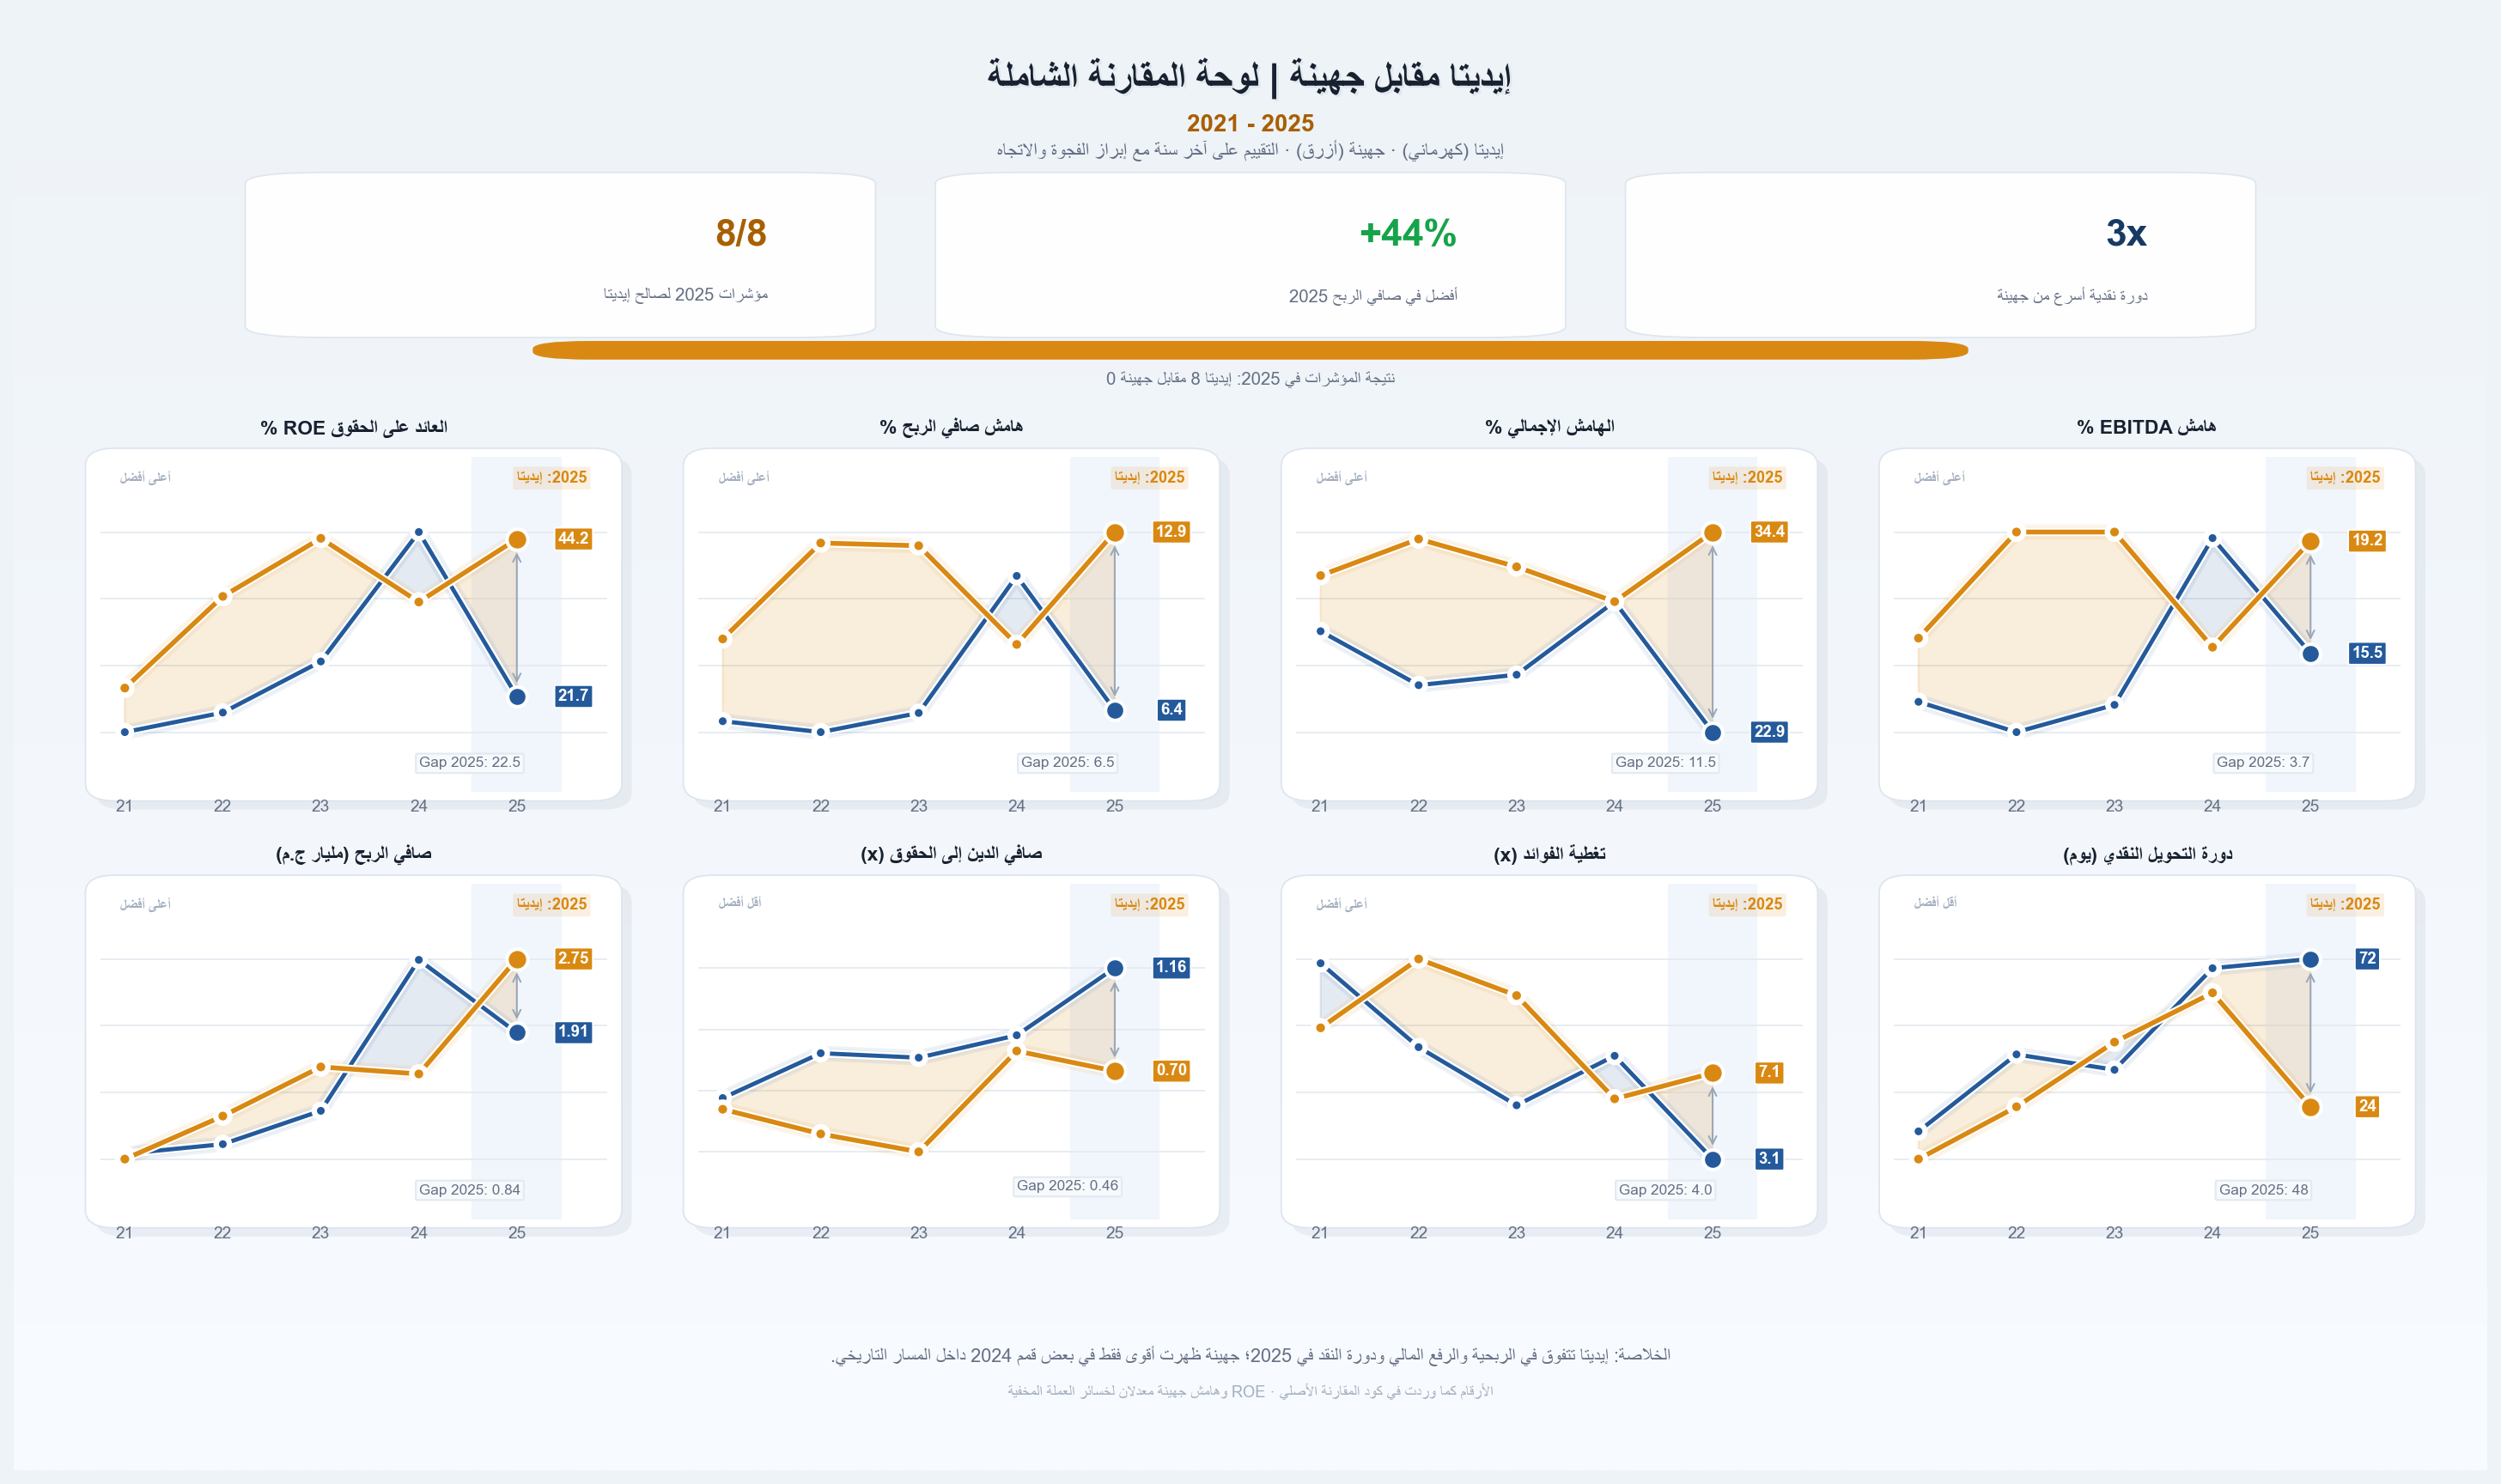

In [17]:
# -*- coding: utf-8 -*-
"""لوحة مقارنة مالية متقدمة: إيديتا vs جهينة 2021-2025."""

import importlib
import subprocess
import sys


for package, module in [("arabic-reshaper", "arabic_reshaper"), ("python-bidi", "bidi")]:
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import arabic_reshaper
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from bidi.algorithm import get_display
from matplotlib.gridspec import GridSpec


def ar(text):
    """Shape Arabic text for Matplotlib."""
    return get_display(arabic_reshaper.reshape(str(text)))


def pick_font():
    preferred = ["Cairo", "Tajawal", "Noto Kufi Arabic", "Noto Sans Arabic", "Arial", "Tahoma", "DejaVu Sans"]
    available = {font.name.lower(): font.name for font in fm.fontManager.ttflist}
    for name in preferred:
        for key, actual in available.items():
            if name.lower() in key:
                return actual
    return "DejaVu Sans"


plt.rcParams.update(
    {
        "font.family": pick_font(),
        "axes.unicode_minus": False,
        "figure.dpi": 160,
        "savefig.dpi": 220,
    }
)


YEARS = ["21", "22", "23", "24", "25"]
X = np.arange(len(YEARS))

# title, Edita, Juhayna, lower_is_better
METRICS = [
    ("العائد على الحقوق ROE %", [22.9, 36.0, 44.3, 35.2, 44.2], [16.6, 19.4, 26.7, 45.2, 21.7], False),
    ("هامش صافي الربح %", [9.0, 12.5, 12.4, 8.8, 12.9], [6.0, 5.6, 6.3, 11.3, 6.4], False),
    ("الهامش الإجمالي %", [31.9, 34.0, 32.4, 30.4, 34.4], [28.7, 25.6, 26.2, 30.4, 22.9], False),
    ("هامش EBITDA %", [16.0, 19.5, 19.5, 15.7, 19.2], [13.9, 12.9, 13.8, 19.3, 15.5], False),
    ("صافي الربح (مليار ج.م)", [0.47, 0.96, 1.52, 1.44, 2.75], [0.53, 0.64, 1.02, 2.74, 1.91], False),
    ("صافي الدين إلى الحقوق (x)", [0.53, 0.42, 0.34, 0.79, 0.70], [0.58, 0.78, 0.76, 0.86, 1.16], True),
    ("تغطية الفوائد (x)", [9.2, 12.4, 10.7, 5.9, 7.1], [12.2, 8.3, 5.6, 7.9, 3.1], False),
    ("دورة التحويل النقدي (يوم)", [7, 24, 45, 61, 24], [16, 41, 36, 69, 72], True),
]


INK = "#17212F"
MUTED = "#667085"
SOFT = "#A3AFBF"
GRID = "#E5EAF0"
BG_TOP = "#F8FBFF"
BG_BOTTOM = "#EEF3F7"
CARD = "#FFFFFF"
AMBER = "#D98912"
AMBER_DARK = "#A85F00"
NAVY = "#245A9B"
NAVY_DARK = "#173A64"
GREEN = "#16A34A"
RED = "#DC2626"


def value_text(value):
    if abs(value) >= 20:
        return f"{value:.0f}" if float(value).is_integer() else f"{value:.1f}"
    if abs(value) >= 3:
        return f"{value:.1f}"
    return f"{value:.2f}"


def edita_wins(edita_last, juhayna_last, lower_is_better):
    return edita_last < juhayna_last if lower_is_better else edita_last > juhayna_last


def add_page_background(fig):
    ax = fig.add_axes([0, 0, 1, 1], zorder=-20)
    gradient = np.linspace(0, 1, 700).reshape(-1, 1)
    top = np.array([248, 251, 255]) / 255
    bottom = np.array([238, 243, 247]) / 255
    img = top * (1 - gradient) + bottom * gradient
    img = np.tile(img[:, None, :], (1, 2, 1))
    ax.imshow(img, extent=[0, 1, 0, 1], origin="lower", aspect="auto")
    ax.axis("off")


def add_card(fig, ax):
    box = ax.get_position()
    shadow = patches.FancyBboxPatch(
        (box.x0 + 0.004, box.y0 - 0.006),
        box.width,
        box.height,
        transform=fig.transFigure,
        boxstyle="round,pad=0.006,rounding_size=0.012",
        linewidth=0,
        facecolor="#B9C4D1",
        alpha=0.22,
        zorder=-2,
    )
    card = patches.FancyBboxPatch(
        (box.x0, box.y0),
        box.width,
        box.height,
        transform=fig.transFigure,
        boxstyle="round,pad=0.006,rounding_size=0.012",
        linewidth=0.8,
        edgecolor="#DDE5EE",
        facecolor=CARD,
        zorder=-1,
    )
    fig.patches.extend([shadow, card])
    ax.set_zorder(2)
    ax.patch.set_alpha(0)


def draw_kpi(ax, x0, width, value, label, color):
    tile = patches.FancyBboxPatch(
        (x0, 0.10),
        width,
        0.50,
        boxstyle="round,pad=0.012,rounding_size=0.035",
        transform=ax.transAxes,
        linewidth=0.8,
        edgecolor="#DDE5EE",
        facecolor="#FFFFFF",
        alpha=0.95,
    )
    ax.add_patch(tile)
    ax.text(x0 + width - 0.035, 0.41, ar(value), ha="right", va="center", fontsize=20, color=color, weight="bold")
    ax.text(x0 + width - 0.035, 0.22, ar(label), ha="right", va="center", fontsize=9.2, color=MUTED)


def draw_header(ax, score_edita, score_juhayna):
    ax.axis("off")
    ax.text(
        0.50,
        0.91,
        ar("إيديتا مقابل جهينة | لوحة المقارنة الشاملة"),
        ha="center",
        va="center",
        fontsize=20,
        weight="bold",
        color=INK,
        path_effects=[pe.withSimplePatchShadow(offset=(1.2, -1.2), shadow_rgbFace="#C6D2DF", alpha=0.35)],
    )
    ax.text(0.50, 0.76, "2021 - 2025", ha="center", va="center", fontsize=12.5, color=AMBER_DARK, weight="bold")
    ax.text(
        0.50,
        0.68,
        ar("إيديتا (كهرماني) · جهينة (أزرق) · التقييم على آخر سنة مع إبراز الفجوة والاتجاه"),
        ha="center",
        va="center",
        fontsize=10.3,
        color=MUTED,
    )

    draw_kpi(ax, 0.075, 0.25, f"{score_edita}/8", "مؤشرات 2025 لصالح إيديتا", AMBER_DARK)
    draw_kpi(ax, 0.375, 0.25, "+44%", "أفضل في صافي الربح 2025", GREEN)
    draw_kpi(ax, 0.675, 0.25, "3x", "دورة نقدية أسرع من جهينة", NAVY_DARK)

    bar_x, bar_y, bar_w, bar_h = 0.19, 0.02, 0.62, 0.055
    track = patches.FancyBboxPatch(
        (bar_x, bar_y),
        bar_w,
        bar_h,
        boxstyle="round,pad=0.002,rounding_size=0.025",
        transform=ax.transAxes,
        facecolor="#DDE5EE",
        edgecolor="none",
    )
    ax.add_patch(track)
    amber_w = bar_w * score_edita / (score_edita + score_juhayna)
    fill = patches.FancyBboxPatch(
        (bar_x, bar_y),
        amber_w,
        bar_h,
        boxstyle="round,pad=0.002,rounding_size=0.025",
        transform=ax.transAxes,
        facecolor=AMBER,
        edgecolor="none",
    )
    ax.add_patch(fill)
    if score_juhayna:
        ax.add_patch(
            patches.Rectangle(
                (bar_x + amber_w, bar_y),
                bar_w - amber_w,
                bar_h,
                transform=ax.transAxes,
                facecolor=NAVY,
                edgecolor="none",
            )
        )
    ax.text(0.50, -0.045, ar(f"نتيجة المؤشرات في 2025: إيديتا {score_edita} مقابل جهينة {score_juhayna}"), ha="center", va="center", fontsize=9.2, color=MUTED)


def smart_offsets(v1, v2, yspan):
    if abs(v1 - v2) < yspan * 0.10:
        return yspan * 0.045, -yspan * 0.045
    return 0, 0


def draw_metric(ax, title, edita_values, juhayna_values, lower_is_better):
    e = np.array(edita_values, dtype=float)
    j = np.array(juhayna_values, dtype=float)
    y_min = float(min(e.min(), j.min()))
    y_max = float(max(e.max(), j.max()))
    yspan = max(y_max - y_min, 1)
    pad = yspan * 0.30

    ax.set_xlim(-0.25, 4.92)
    ax.set_ylim(y_min - pad, y_max + pad * 1.25)
    ax.axvspan(3.55, 4.45, color="#F1F6FD", zorder=0)

    for grid_y in np.linspace(y_min, y_max, 4):
        ax.axhline(grid_y, color=GRID, lw=0.8, zorder=0)

    editas_good = (e > j) if not lower_is_better else (e < j)
    ax.fill_between(X, e, j, where=editas_good, interpolate=True, color=AMBER, alpha=0.15, zorder=1)
    ax.fill_between(X, e, j, where=~editas_good, interpolate=True, color=NAVY, alpha=0.12, zorder=1)

    for width, alpha in [(8, 0.08), (5, 0.12)]:
        ax.plot(X, j, color=NAVY, lw=width, alpha=alpha, solid_capstyle="round", zorder=2)
        ax.plot(X, e, color=AMBER, lw=width, alpha=alpha, solid_capstyle="round", zorder=2)

    line_fx = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]
    ax.plot(X, j, color=NAVY, lw=2.2, marker="o", ms=5.3, mec="white", mew=1.2, zorder=4, path_effects=line_fx)
    ax.plot(X, e, color=AMBER, lw=2.5, marker="o", ms=5.8, mec="white", mew=1.2, zorder=5, path_effects=line_fx)

    ax.scatter([4], [e[-1]], s=120, color=AMBER, edgecolor="white", linewidth=1.8, zorder=8)
    ax.scatter([4], [j[-1]], s=104, color=NAVY, edgecolor="white", linewidth=1.8, zorder=7)

    e_winner = edita_wins(e[-1], j[-1], lower_is_better)
    winner_name = "إيديتا" if e_winner else "جهينة"
    winner_color = AMBER if e_winner else NAVY
    gap = abs(e[-1] - j[-1])
    direction = "أقل أفضل" if lower_is_better else "أعلى أفضل"

    ax.text(
        0.96,
        0.96,
        ar(f"2025: {winner_name}"),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.2,
        color=winner_color,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.24,rounding_size=0.12", facecolor=winner_color, alpha=0.12, edgecolor="none"),
    )
    ax.text(
        0.04,
        0.96,
        ar(direction),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7.4,
        color=SOFT,
        weight="bold",
    )

    off_e, off_j = smart_offsets(e[-1], j[-1], yspan)
    ax.text(
        4.58,
        e[-1] + off_e,
        value_text(e[-1]),
        ha="center",
        va="center",
        fontsize=8.4,
        color="white",
        weight="bold",
        clip_on=False,
        bbox=dict(boxstyle="round,pad=0.22,rounding_size=0.10", facecolor=AMBER, edgecolor="white", linewidth=0.8),
    )
    ax.text(
        4.58,
        j[-1] + off_j,
        value_text(j[-1]),
        ha="center",
        va="center",
        fontsize=8.4,
        color="white",
        weight="bold",
        clip_on=False,
        bbox=dict(boxstyle="round,pad=0.22,rounding_size=0.10", facecolor=NAVY, edgecolor="white", linewidth=0.8),
    )

    label_y = y_min - pad * 0.52
    ax.annotate(
        "",
        xy=(4, e[-1]),
        xytext=(4, j[-1]),
        arrowprops=dict(arrowstyle="<->", color="#9AA7B5", lw=0.9, shrinkA=7, shrinkB=7),
        zorder=3,
    )
    ax.text(
        3.52,
        label_y,
        f"Gap 2025: {value_text(gap)}",
        ha="center",
        va="center",
        fontsize=7.7,
        color=MUTED,
        bbox=dict(boxstyle="round,pad=0.22,rounding_size=0.10", facecolor="#F7FAFC", edgecolor="#E3EAF2"),
    )

    title_text = title
    ax.set_title(ar(title_text), fontsize=10.3, color=INK, weight="bold", pad=12)
    ax.set_xticks(X)
    ax.set_xticklabels(YEARS, fontsize=8.6, color=MUTED)
    ax.set_yticks([])
    ax.tick_params(axis="x", length=0, pad=4)
    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_footer(ax):
    ax.axis("off")
    note = "الخلاصة: إيديتا تتفوق في الربحية والرفع المالي ودورة النقد في 2025؛ جهينة ظهرت أقوى فقط في بعض قمم 2024 داخل المسار التاريخي."
    ax.text(0.5, 0.52, ar(note), ha="center", va="center", fontsize=9.8, color=MUTED)
    ax.text(
        0.5,
        0.14,
        ar("الأرقام كما وردت في كود المقارنة الأصلي · ROE وهامش جهينة معدلان لخسائر العملة المخفية"),
        ha="center",
        va="center",
        fontsize=8.2,
        color=SOFT,
    )


score_edita = sum(edita_wins(e[-1], j[-1], low) for _, e, j, low in METRICS)
score_juhayna = len(METRICS) - score_edita

fig = plt.figure(figsize=(18, 10.6), facecolor=BG_BOTTOM)
add_page_background(fig)

gs = GridSpec(
    4,
    4,
    figure=fig,
    left=0.035,
    right=0.965,
    top=0.975,
    bottom=0.045,
    height_ratios=[0.94, 1.0, 1.0, 0.28],
    hspace=0.34,
    wspace=0.18,
)

header_ax = fig.add_subplot(gs[0, :])
draw_header(header_ax, score_edita, score_juhayna)

metric_axes = [fig.add_subplot(gs[row, col]) for row in [1, 2] for col in range(4)]
for axis in metric_axes:
    add_card(fig, axis)

for axis, metric in zip(metric_axes, METRICS):
    draw_metric(axis, *metric)

footer_ax = fig.add_subplot(gs[3, :])
draw_footer(footer_ax)

fig.savefig("dashboard_edita_vs_juhayna_v2.png", bbox_inches="tight", facecolor=BG_BOTTOM)
fig.savefig("dashboard_edita_vs_juhayna_v2.pdf", bbox_inches="tight", facecolor=BG_BOTTOM)
print("Saved: dashboard_edita_vs_juhayna_v2.png and dashboard_edita_vs_juhayna_v2.pdf")
plt.show()


**إيديتا تتفوّق على جهينة في الربحية والملاءة وكفاءة رأس المال العامل، ويقتصر تفوّق جهينة على الحجم ودوران الأصول — ما يجعل إيديتا الأقدر على التحكّم في ربحها والأصمد في الأزمات.**

## Liquidaity Ratios

Saved: liquidity_dashboard_final.png / .pdf


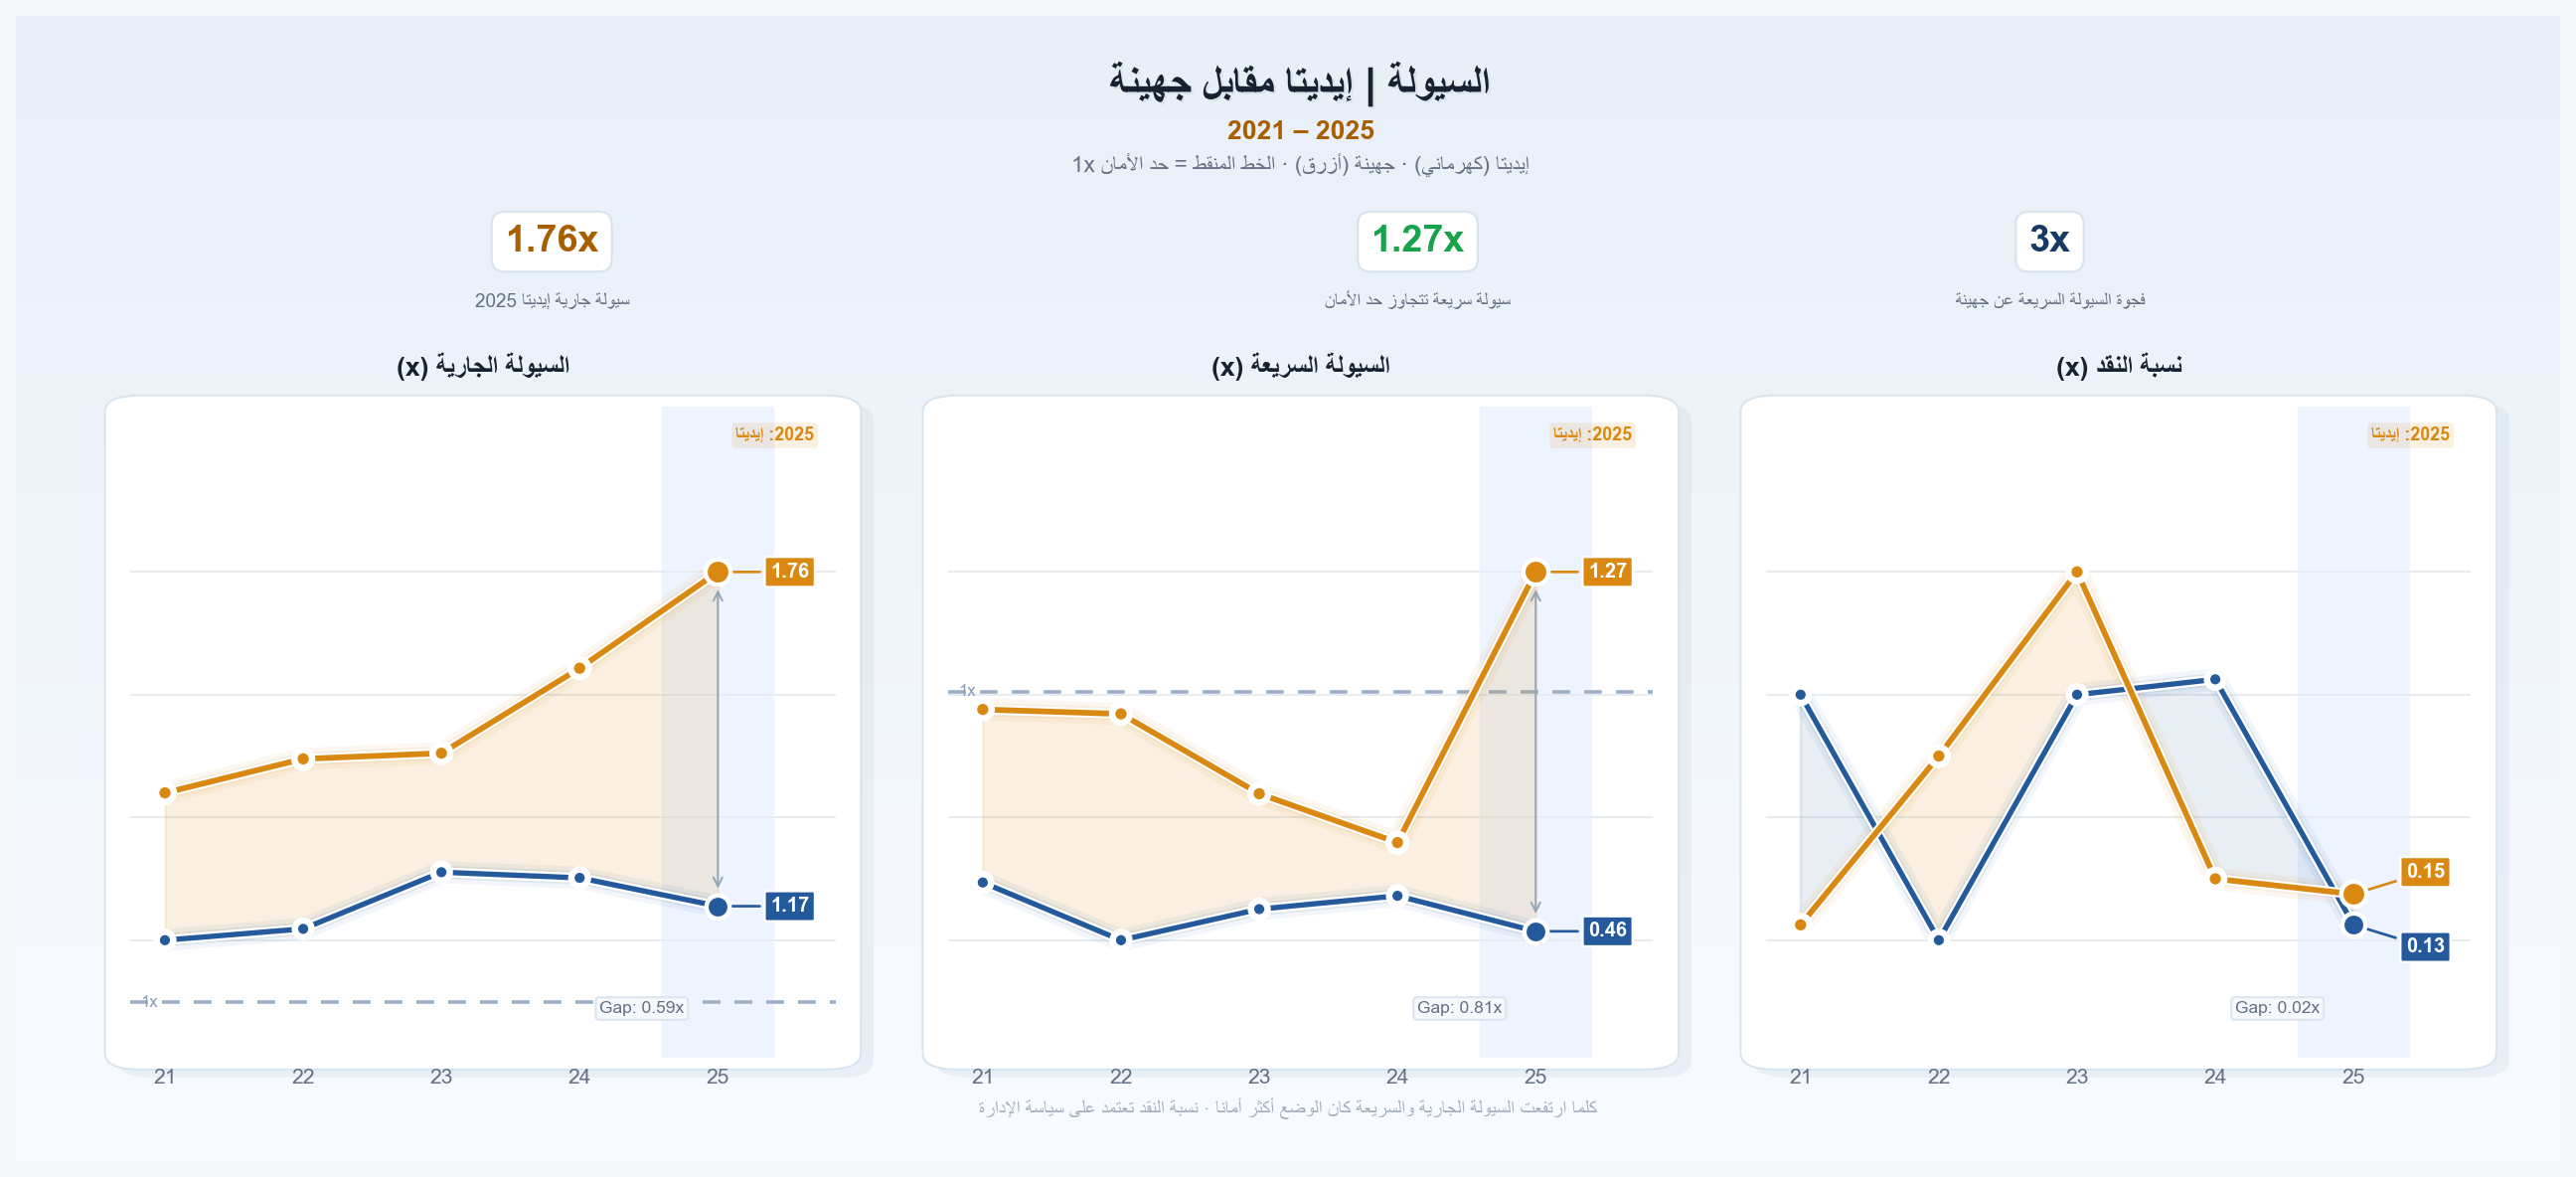

In [29]:
# -*- coding: utf-8 -*-
"""Liquidity Dashboard | Edita vs Juhayna 2021–2025 — نسخة متطورة"""

import importlib
import subprocess
import sys

for pkg, mod in [("arabic-reshaper", "arabic_reshaper"), ("python-bidi", "bidi")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import arabic_reshaper
import matplotlib.font_manager as fm
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from bidi.algorithm import get_display
from matplotlib.gridspec import GridSpec


def ar(txt):
    return get_display(arabic_reshaper.reshape(str(txt)))


def pick_font():
    available = {f.name.lower(): f.name for f in fm.fontManager.ttflist}
    for name in ["Cairo", "Tajawal", "Noto Kufi Arabic", "Arial", "Tahoma", "DejaVu Sans"]:
        for key, actual in available.items():
            if name.lower() in key:
                return actual
    return "DejaVu Sans"

plt.rcParams.update({"font.family": pick_font(), "axes.unicode_minus": False,
                      "figure.dpi": 160, "savefig.dpi": 220})

INK        = "#17212F"
AMBER      = "#D98912"
AMBER_DARK = "#A85F00"
NAVY       = "#245A9B"
NAVY_DARK  = "#173A64"
MUTED      = "#667085"
SOFT       = "#A3AFBF"
GRID_C     = "#E5EAF0"
BG         = "#F4F7FA"
CARD       = "#FFFFFF"
HL         = "#EEF4FF"
GREEN      = "#16A34A"

YEARS = ["21", "22", "23", "24", "25"]
X     = np.arange(5)

METRICS = [
    ("السيولة الجارية (x)",  [1.37,1.43,1.44,1.59,1.76], [1.11,1.13,1.23,1.22,1.17], 1.0),
    ("السيولة السريعة (x)",  [0.96,0.95,0.77,0.66,1.27], [0.57,0.44,0.51,0.54,0.46], 1.0),
    ("نسبة النقد (x)",       [0.13,0.24,0.36,0.16,0.15], [0.28,0.12,0.28,0.29,0.13], None),
]

def add_bg(fig):
    ax = fig.add_axes([0, 0, 1, 1], zorder=-20)
    grad = np.linspace(0, 1, 600).reshape(-1, 1)
    top    = np.array([248, 251, 255]) / 255
    bottom = np.array([232, 239, 247]) / 255
    img = top * (1 - grad) + bottom * grad
    img = np.tile(img[:, None, :], (1, 2, 1))
    ax.imshow(img, extent=[0,1,0,1], origin="lower", aspect="auto")
    ax.axis("off")

def add_card(fig, ax):
    box = ax.get_position()
    fig.patches.extend([
        patches.FancyBboxPatch(
            (box.x0+.005, box.y0-.007), box.width, box.height,
            transform=fig.transFigure,
            boxstyle="round,pad=.010,rounding_size=.014",
            facecolor="#B8C6D6", alpha=.20, linewidth=0, zorder=-3),
        patches.FancyBboxPatch(
            (box.x0, box.y0), box.width, box.height,
            transform=fig.transFigure,
            boxstyle="round,pad=.010,rounding_size=.014",
            facecolor=CARD, edgecolor="#D8E4EE", linewidth=.9, zorder=-2),
    ])
    ax.set_zorder(2)
    ax.patch.set_alpha(0)

def draw_metric(ax, title, edita, juhayna, ref):
    e = np.array(edita,  dtype=float)
    j = np.array(juhayna, dtype=float)

    y_min = float(min(e.min(), j.min()))
    y_max = float(max(e.max(), j.max()))
    yspan = max(y_max - y_min, .05)
    pad   = yspan * .32

    ax.set_xlim(-.25, 4.85)
    ax.set_ylim(y_min - pad, y_max + pad * 1.4)
    ax.axvspan(3.6, 4.4, color=HL, zorder=0)

    for yy in np.linspace(y_min, y_max, 4):
        ax.axhline(yy, color=GRID_C, lw=.8, zorder=0)

    if ref is not None:
        ax.axhline(ref, color="#9BAFC4", lw=1.6, ls=(0, (5, 4)), zorder=1)
        ax.text(-.18, ref, f"{ref:.0f}x", fontsize=7.5, color="#8A9DB2", va="center", ha="left")

    e_leads = e > j
    ax.fill_between(X, e, j, where=e_leads,  interpolate=True, color=AMBER, alpha=.13, zorder=1)
    ax.fill_between(X, e, j, where=~e_leads, interpolate=True, color=NAVY,  alpha=.10, zorder=1)

    for lw, alpha in [(10, .06), (6, .10)]:
        ax.plot(X, j, color=NAVY,  lw=lw, alpha=alpha, solid_capstyle="round", zorder=2)
        ax.plot(X, e, color=AMBER, lw=lw, alpha=alpha, solid_capstyle="round", zorder=2)

    fx = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]
    ax.plot(X, j, color=NAVY,  lw=2.4, marker="o", ms=6,   mec="white", mew=1.4, zorder=4, path_effects=fx)
    ax.plot(X, e, color=AMBER, lw=2.6, marker="o", ms=6.5, mec="white", mew=1.4, zorder=5, path_effects=fx)

    ax.scatter([4], [e[-1]], s=130, color=AMBER, edgecolor="white", linewidth=2, zorder=8)
    ax.scatter([4], [j[-1]], s=110, color=NAVY,  edgecolor="white", linewidth=2, zorder=7)

    gap = abs(e[-1] - j[-1])
    off = yspan * .06 if gap < yspan * .12 else 0

    for val, color, dy in [(e[-1], AMBER, off), (j[-1], NAVY, -off)]:
        ax.annotate(
            f"{val:.2f}",
            xy=(4, val), xytext=(4.52, val + dy),
            fontsize=9, weight="bold", color="white",
            ha="center", va="center", clip_on=False,
            bbox=dict(boxstyle="round,pad=.28,rounding_size=.10", fc=color, ec="white", lw=1),
            arrowprops=dict(arrowstyle="-", lw=1.2, color=color),
        )

    ax.annotate("", xy=(4, e[-1]), xytext=(4, j[-1]),
                arrowprops=dict(arrowstyle="<->", color="#96A6B5", lw=.9, shrinkA=8, shrinkB=8), zorder=3)
    ax.text(3.45, y_min - pad * .58, f"Gap: {gap:.2f}x", ha="center", va="center",
            fontsize=7.8, color=MUTED,
            bbox=dict(boxstyle="round,pad=.22", fc="#F6F9FC", ec="#DDE6EF"))

    e_wins = e[-1] > j[-1]
    winner = "إيديتا" if e_wins else "جهينة"
    wcolor = AMBER if e_wins else NAVY
    ax.text(.97, .97, ar(f"2025: {winner}"),
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color=wcolor, weight="bold",
            bbox=dict(boxstyle="round,pad=.22", fc=wcolor, alpha=.12, ec="none"))

    ax.set_title(ar(title), fontsize=12, color=INK, weight="bold", pad=14)
    ax.set_xticks(X)
    ax.set_xticklabels(YEARS, fontsize=9.5, color=MUTED)
    ax.set_yticks([])
    ax.tick_params(axis="x", length=0, pad=5)
    for s in ax.spines.values():
        s.set_visible(False)

fig = plt.figure(figsize=(16, 7.2), facecolor=BG)
add_bg(fig)

gs = GridSpec(2, 3, figure=fig,
              left=.045, right=.965,
              top=.97, bottom=.09,
              height_ratios=[.42, 1],
              hspace=.18, wspace=.16)

header = fig.add_subplot(gs[0, :])
header.axis("off")

header.text(.5, .96, ar("السيولة | إيديتا مقابل جهينة"),
            ha="center", va="top", fontsize=19, weight="bold", color=INK,
            path_effects=[pe.withSimplePatchShadow(offset=(1,-1), shadow_rgbFace="#BDC9D8", alpha=.30)])
header.text(.5, .70, "2021 – 2025",
            ha="center", va="center", fontsize=12, color=AMBER_DARK, weight="bold")
header.text(.5, .58, ar("إيديتا (كهرماني) · جهينة (أزرق) · الخط المنقط = حد الأمان 1x"),
            ha="center", va="center", fontsize=10, color=MUTED)

for kx, val, lbl, clr in [
    (.18, "1.76x", "سيولة جارية إيديتا 2025", AMBER_DARK),
    (.55, "1.27x", "سيولة سريعة تتجاوز حد الأمان", GREEN),
    (.82, "3x",    "فجوة السيولة السريعة عن جهينة", NAVY_DARK),
]:
    header.text(kx, .30, ar(val), ha="center", va="center",
                fontsize=17, color=clr, weight="bold",
                bbox=dict(boxstyle="round,pad=.35", fc=CARD, ec="#D8E4EE", linewidth=1))
    header.text(kx, .08, ar(lbl), ha="center", va="center", fontsize=8.5, color=MUTED)

metric_axes = [fig.add_subplot(gs[1, c]) for c in range(3)]
for ax in metric_axes:
    add_card(fig, ax)
for ax, (title, e, j, ref) in zip(metric_axes, METRICS):
    draw_metric(ax, title, e, j, ref)

fig.text(.5, .04,
         ar("كلما ارتفعت السيولة الجارية والسريعة كان الوضع أكثر أمانًا · نسبة النقد تعتمد على سياسة الإدارة"),
         ha="center", fontsize=9, color=SOFT)

fig.savefig("liquidity_dashboard_final.png", dpi=220, bbox_inches="tight", facecolor=BG)
fig.savefig("liquidity_dashboard_final.pdf",           bbox_inches="tight", facecolor=BG)
print("Saved: liquidity_dashboard_final.png / .pdf")
plt.show()


**إيديتا تحتفظ بوسادة سيولة اقوي في التحسّن (جارية 1.76 وسريعة 1.27 في 2025)، بينما تعمل جهينة بهامش أضيق وتعتمد على المخزون (سريعة ~0.5 فقط) — ميزة أمان لإيديتا مع تصاعد مديونية جهينة.**

## التقييم

**(P/E, EV/EBITDA)**

Saved: valuation_multiples.png / .pdf


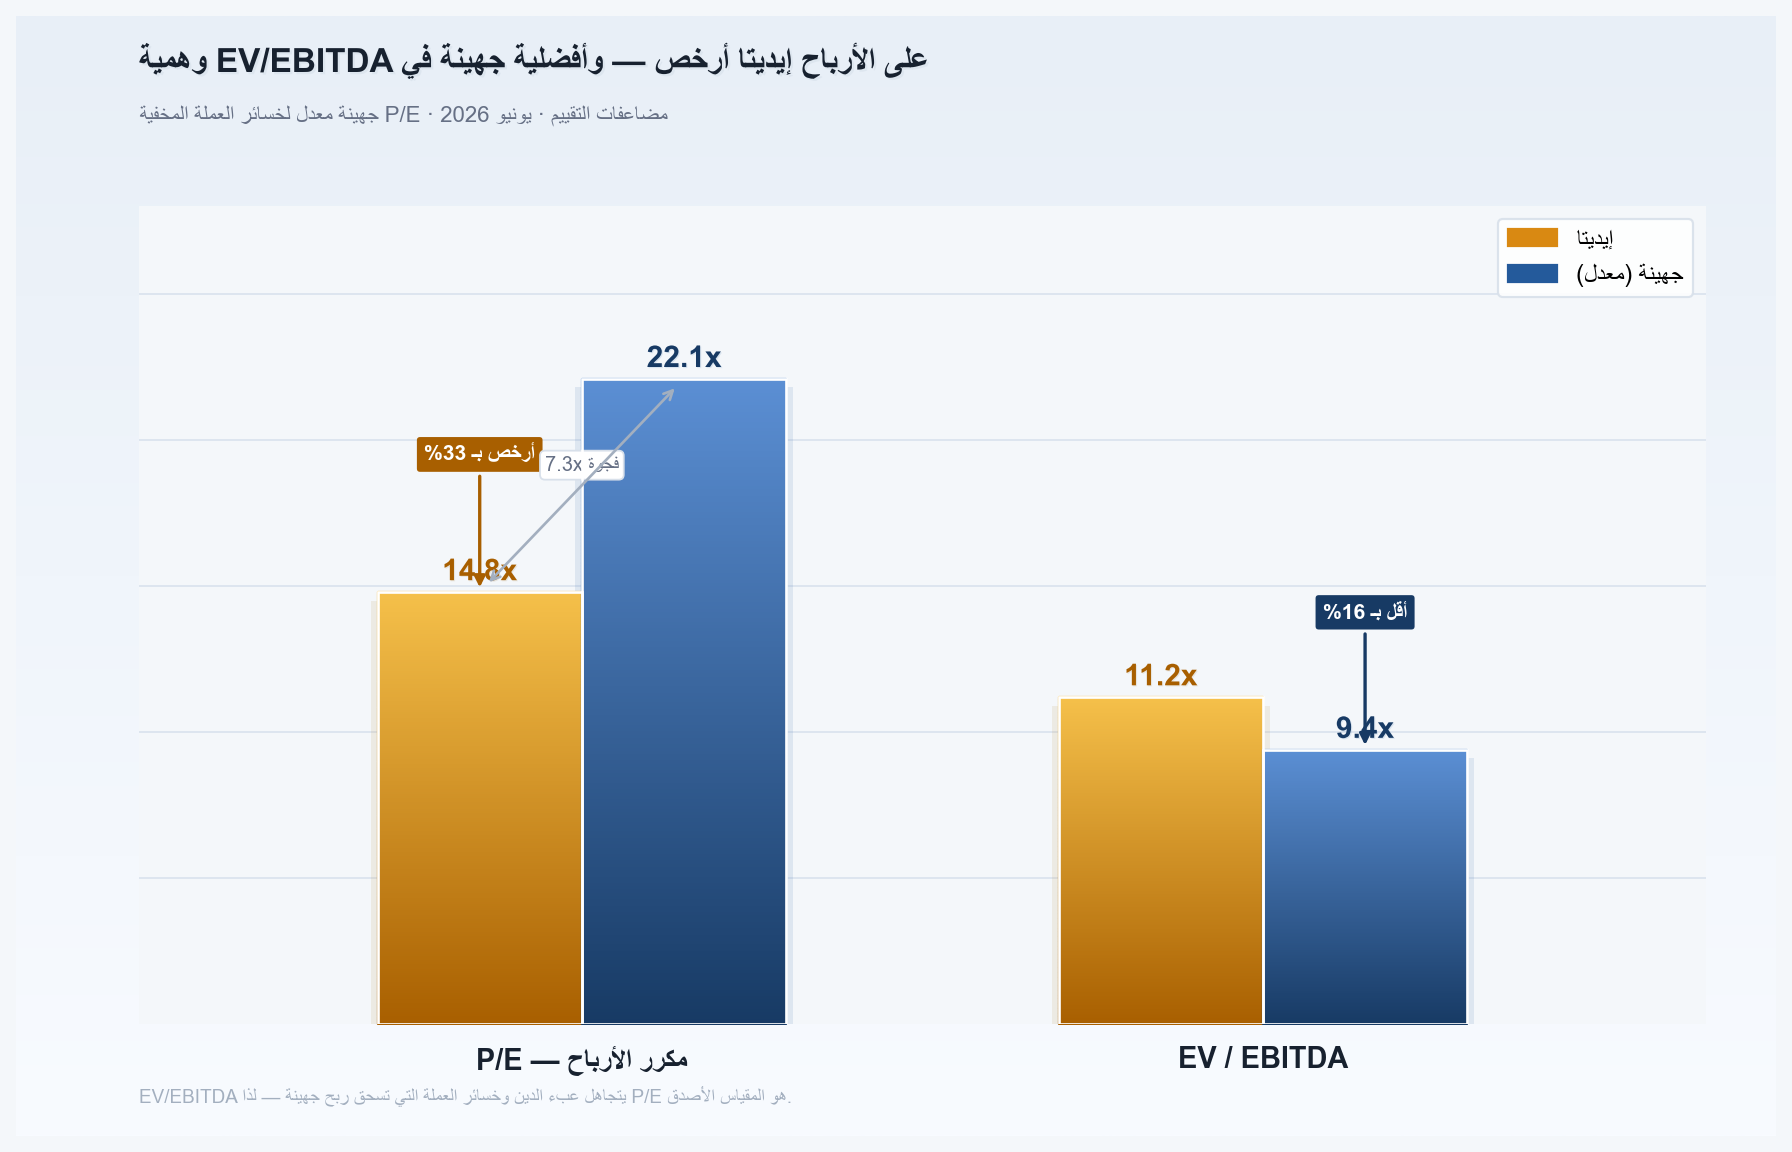

In [37]:
# -*- coding: utf-8 -*-
"""تقييم: مضاعفات إيديتا vs جهينة — نسخة متطورة بصرياً"""

import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap

# ── خط ──────────────────────────────────────────────────────────────────────
def pick_font():
    available = {f.name.lower(): f.name for f in fm.fontManager.ttflist}
    for name in ["Cairo","Tajawal","Arial","Tahoma","DejaVu Sans"]:
        for key, actual in available.items():
            if name.lower() in key: return actual
    return "DejaVu Sans"

plt.rcParams.update({"font.family": pick_font(),
                      "axes.unicode_minus": False, "savefig.dpi": 220})

# ── ألوان ────────────────────────────────────────────────────────────────────
INK        = "#17212F"
AMBER      = "#D98912"
AMBER_L    = "#F5C04A"
AMBER_DARK = "#A85F00"
NAVY       = "#245A9B"
NAVY_L     = "#5B8FD4"
NAVY_DARK  = "#173A64"
MUTED      = "#667085"
SOFT       = "#A3AFBF"
BG         = "#F4F7FA"
CARD       = "#FFFFFF"
RED        = "#C0392B"
GREEN      = "#16A34A"

# ── بيانات ───────────────────────────────────────────────────────────────────
edita   = [14.8, 11.2]
juhayna = [22.1,  9.4]
groups  = ["P/E", "EV/EBITDA"]
labels_ar = [ar("P/E — مكرر الأرباح"), ar("EV / EBITDA")]

# ── دالة رسم بار متدرج ───────────────────────────────────────────────────────
def grad_bar(ax, xc, height, width, color_top, color_bot, zorder=3, alpha=1.0):
    n = 200
    for i in range(n):
        frac = i / n
        r1,g1,b1 = [int(color_bot[j:j+2],16)/255 for j in (1,3,5)]
        r2,g2,b2 = [int(color_top[j:j+2],16)/255 for j in (1,3,5)]
        c = (r1+(r2-r1)*frac, g1+(g2-g1)*frac, b1+(b2-b1)*frac)
        y0 = height * i / n
        y1 = height * (i+1) / n
        ax.fill_between([xc-width/2, xc+width/2], [y0,y0], [y1,y1],
                        color=c, zorder=zorder, alpha=alpha)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7), dpi=160, facecolor=BG)
ax.set_facecolor(BG)

# خلفية متدرجة
grad = np.linspace(0, 1, 400).reshape(-1, 1)
top    = np.array([248,251,255])/255
bottom = np.array([232,239,247])/255
img = top*(1-grad) + bottom*grad
img = np.tile(img[:,None,:], (1,2,1))
ax_bg = fig.add_axes([0,0,1,1], zorder=-10)
ax_bg.imshow(img, extent=[0,1,0,1], origin="lower", aspect="auto")
ax_bg.axis("off")

w = 0.30
x = np.arange(2)

# ── الأعمدة ──────────────────────────────────────────────────────────────────
for i, (e, j) in enumerate(zip(edita, juhayna)):
    # ظل خفيف
    ax.bar(i-w/2, e, w+.02, color="#C4A060", alpha=.15, zorder=2,
           bottom=-.3, edgecolor="none")
    ax.bar(i+w/2, j, w+.02, color="#3A6EAE", alpha=.12, zorder=2,
           bottom=-.3, edgecolor="none")
    # أعمدة متدرجة
    grad_bar(ax, i-w/2, e, w, AMBER_L, AMBER_DARK, zorder=3)
    grad_bar(ax, i+w/2, j, w, NAVY_L,  NAVY_DARK,  zorder=3)
    # حافة بيضاء
    ax.bar(i-w/2, e, w, color="none", edgecolor="white", lw=1.2, zorder=4)
    ax.bar(i+w/2, j, w, color="none", edgecolor="white", lw=1.2, zorder=4)

# ── تسميات القيم ─────────────────────────────────────────────────────────────
for i, (e, j) in enumerate(zip(edita, juhayna)):
    # إيديتا
    winner_e = e < j  # أقل = أرخص = أفضل
    ax.text(i-w/2, e+.4, f"{e:.1f}x", ha="center", fontsize=13.5,
            color=AMBER_DARK, weight="bold",
            path_effects=[pe.withSimplePatchShadow(offset=(.5,-.5),
                          shadow_rgbFace="#C4B090", alpha=.25)])
    # جهينة
    ax.text(i+w/2, j+.4, f"{j:.1f}x", ha="center", fontsize=13.5,
            color=NAVY_DARK, weight="bold",
            path_effects=[pe.withSimplePatchShadow(offset=(.5,-.5),
                          shadow_rgbFace="#8AAED0", alpha=.25)])

# ── شارة الفائز ──────────────────────────────────────────────────────────────
win_data = [
    (0, edita[0], juhayna[0], ar("أرخص بـ 33%"), AMBER_DARK),
    (1, juhayna[1], edita[1], ar("أقل بـ 16%"), NAVY_DARK),
]
for xi, winner_val, loser_val, label, color in win_data:
    xpos = xi - w/2 if color == AMBER_DARK else xi + w/2
    ax.annotate(label,
                xy=(xpos, winner_val),
                xytext=(xpos, winner_val + 4.5),
                ha="center", fontsize=9.5, color="white", weight="bold",
                bbox=dict(boxstyle="round,pad=.35,rounding_size=.15",
                          fc=color, ec="none"),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=1.5, mutation_scale=10))

# ── سهم مقارنة P/E ───────────────────────────────────────────────────────────
ax.annotate("", xy=(0-w/2, edita[0]), xytext=(0+w/2, juhayna[0]),
            arrowprops=dict(arrowstyle="<->", color=SOFT, lw=1.2,
                            shrinkA=6, shrinkB=6), zorder=5)
ax.text(0, (edita[0]+juhayna[0])/2 + .5, ar("فجوة 7.3x"),
        ha="center", fontsize=9, color=MUTED,
        bbox=dict(boxstyle="round,pad=.25", fc=CARD, ec="#D8E0EA", lw=.8))

# ── خطوط شبكة ────────────────────────────────────────────────────────────────
for yy in [5, 10, 15, 20, 25]:
    ax.axhline(yy, color="#DDE5EF", lw=.9, zorder=1)

# ── محاور ────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(labels_ar, fontsize=13, color=INK, weight="bold")
ax.tick_params(axis="x", pad=10)
ax.set_yticks([])
ax.set_ylim(0, 28)
ax.set_xlim(-.65, 1.65)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)

# ── أسطورة ────────────────────────────────────────────────────────────────────
leg = [mpatches.Patch(color=AMBER, label=ar("إيديتا")),
       mpatches.Patch(color=NAVY,  label=ar("جهينة (معدّل)"))]
ax.legend(handles=leg, loc="upper right", fontsize=11,
          framealpha=.9, edgecolor="#D8E0EA", fancybox=True)

# ── نصوص ─────────────────────────────────────────────────────────────────────
fig.text(.07, .95, ar("على الأرباح إيديتا أرخص — وأفضلية جهينة في EV/EBITDA وهمية"),
         ha="left", fontsize=15, color=INK, weight="bold",
         path_effects=[pe.withSimplePatchShadow(offset=(1,-1),
                       shadow_rgbFace="#C6D2DF", alpha=.30)])
fig.text(.07, .905, ar("مضاعفات التقييم · يونيو 2026 · P/E جهينة معدّل لخسائر العملة المخفية"),
         ha="left", fontsize=10, color=MUTED)
fig.text(.07, .03,
         ar("EV/EBITDA يتجاهل عبء الدين وخسائر العملة التي تسحق ربح جهينة — لذا P/E هو المقياس الأصدق."),
         ha="left", fontsize=8.5, color=SOFT)

plt.subplots_adjust(left=.07, right=.96, top=.83, bottom=.10)
plt.savefig("valuation_multiples.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.savefig("valuation_multiples.pdf",           bbox_inches="tight", facecolor=BG)
print("Saved: valuation_multiples.png / .pdf")
plt.show()


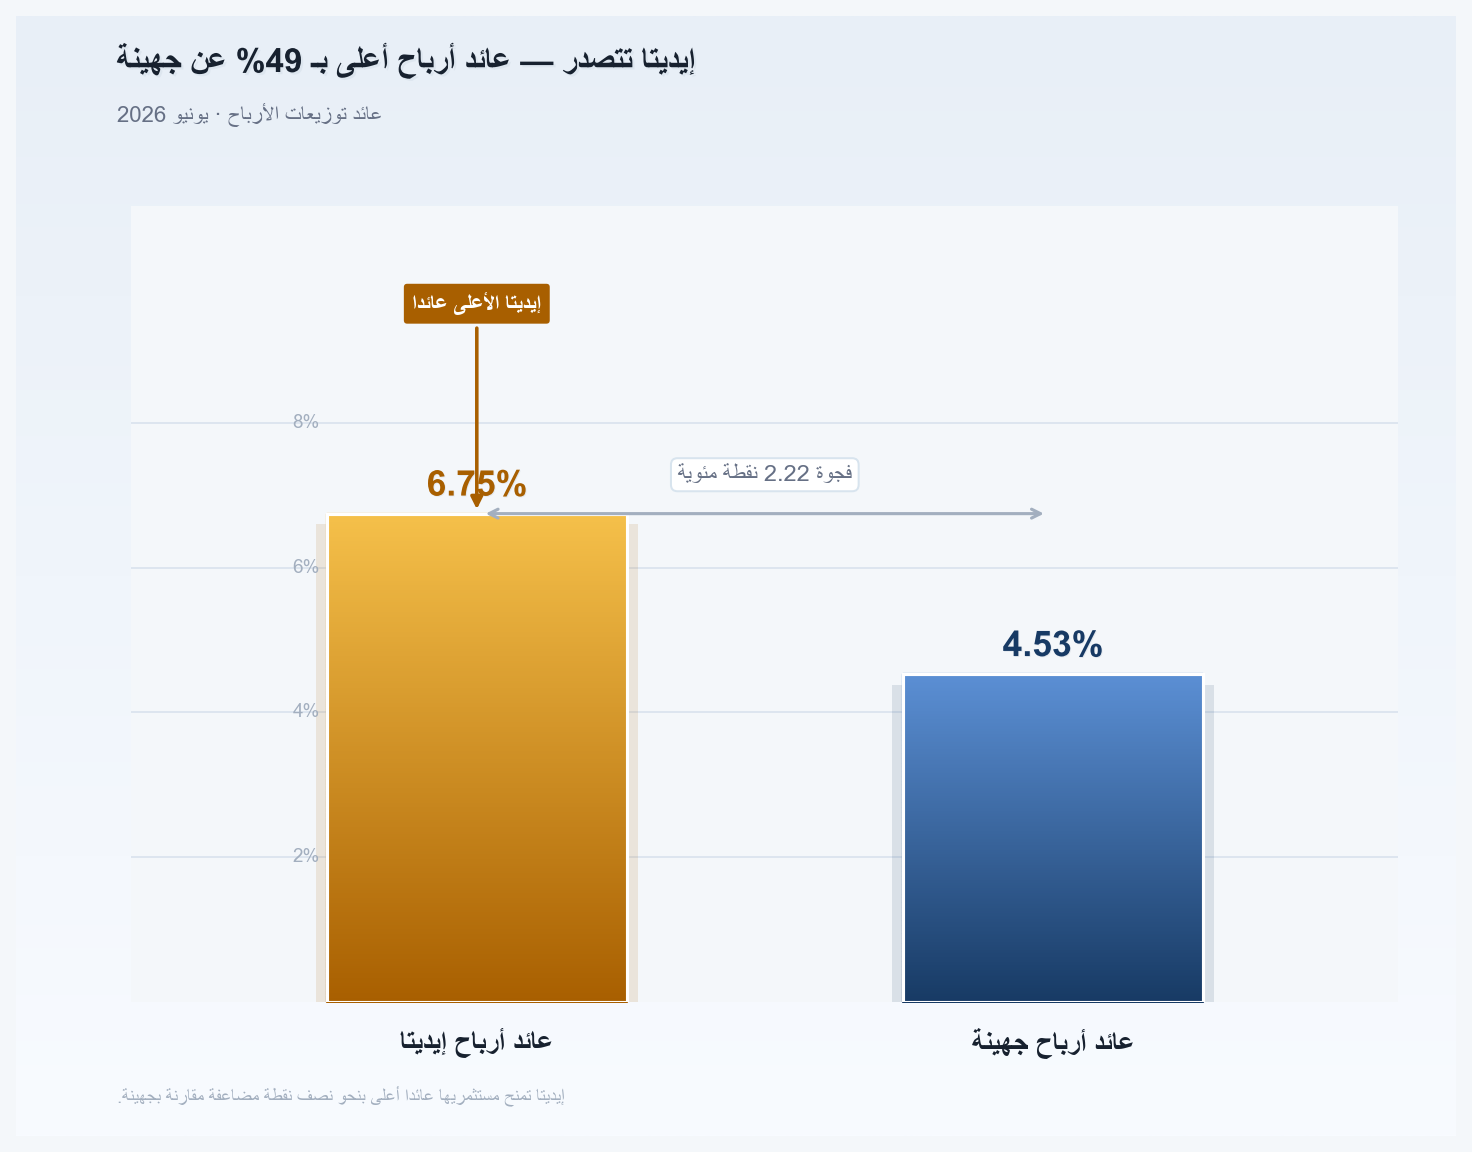

In [39]:
# -*- coding: utf-8 -*-
"""تقييم: عائد الأرباح — إيديتا vs جهينة"""

import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.font_manager as fm

def pick_font():
    available = {f.name.lower(): f.name for f in fm.fontManager.ttflist}
    for name in ["Cairo","Tajawal","Arial","Tahoma","DejaVu Sans"]:
        for key, actual in available.items():
            if name.lower() in key: return actual
    return "DejaVu Sans"

plt.rcParams.update({"font.family": pick_font(),
                      "axes.unicode_minus": False, "savefig.dpi": 220})

INK        = "#17212F"
AMBER_L    = "#F5C04A"
AMBER_DARK = "#A85F00"
NAVY_L     = "#5B8FD4"
NAVY_DARK  = "#173A64"
MUTED      = "#667085"
SOFT       = "#A3AFBF"
BG         = "#F4F7FA"
CARD       = "#FFFFFF"

vals     = [6.75, 4.53]
cols_top = [AMBER_L, NAVY_L]
cols_bot = [AMBER_DARK, NAVY_DARK]
labels   = [ar("عائد أرباح إيديتا"), ar("عائد أرباح جهينة")]
x        = np.arange(2)

def grad_bar(ax, xc, height, width, ctop, cbot, zorder=3):
    n = 200
    for i in range(n):
        frac = i / n
        r1,g1,b1 = [int(cbot[j:j+2],16)/255 for j in (1,3,5)]
        r2,g2,b2 = [int(ctop[j:j+2],16)/255 for j in (1,3,5)]
        c = (r1+(r2-r1)*frac, g1+(g2-g1)*frac, b1+(b2-b1)*frac)
        ax.fill_between([xc-width/2, xc+width/2],
                        [height*i/n]*2, [height*(i+1)/n]*2,
                        color=c, zorder=zorder)

fig, ax = plt.subplots(figsize=(9, 7), dpi=160, facecolor=BG)
ax.set_facecolor(BG)

grad  = np.linspace(0, 1, 400).reshape(-1, 1)
top_c = np.array([248,251,255])/255
bot_c = np.array([232,239,247])/255
img   = top_c*(1-grad) + bot_c*grad
img   = np.tile(img[:,None,:], (1,2,1))
ax_bg = fig.add_axes([0,0,1,1], zorder=-10)
ax_bg.imshow(img, extent=[0,1,0,1], origin="lower", aspect="auto")
ax_bg.axis("off")

w = 0.52
for i, (v, ct, cb) in enumerate(zip(vals, cols_top, cols_bot)):
    ax.bar(i, v, w+.04, color=cb, alpha=.12, zorder=2, bottom=-.15, edgecolor="none")
    grad_bar(ax, i, v, w, ct, cb, zorder=3)
    ax.bar(i, v, w, color="none", edgecolor="white", lw=1.4, zorder=4)

for i, (v, tc) in enumerate(zip(vals, [AMBER_DARK, NAVY_DARK])):
    ax.text(i, v+.25, f"{v:.2f}%", ha="center", fontsize=16, color=tc, weight="bold",
            path_effects=[pe.withSimplePatchShadow(offset=(.4,-.4),
                          shadow_rgbFace=SOFT, alpha=.20)])

gap = vals[0] - vals[1]
ax.annotate("", xy=(0, vals[0]), xytext=(1, vals[0]),
            arrowprops=dict(arrowstyle="<->", color=SOFT, lw=1.4, shrinkA=4, shrinkB=4), zorder=6)
ax.text(.5, vals[0]+.4, ar(f"فجوة {gap:.2f} نقطة مئوية"),
        ha="center", fontsize=10.5, color=MUTED, va="bottom",
        bbox=dict(boxstyle="round,pad=.28", fc=CARD, ec="#D8E4EE", lw=.9))

ax.annotate(ar("إيديتا الأعلى عائداً"),
            xy=(0, vals[0]), xytext=(0, vals[0]+2.8),
            ha="center", fontsize=10, color="white", weight="bold",
            bbox=dict(boxstyle="round,pad=.38,rounding_size=.15", fc=AMBER_DARK, ec="none"),
            arrowprops=dict(arrowstyle="-|>", color=AMBER_DARK, lw=1.6, mutation_scale=11))

for yy in [2, 4, 6, 8]:
    ax.axhline(yy, color="#DDE5EF", lw=.9, zorder=1)
    ax.text(-.32, yy, f"{yy}%", fontsize=8.5, color=SOFT, va="center")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13, color=INK, weight="bold")
ax.tick_params(axis="x", pad=12, length=0)
ax.set_yticks([])
ax.set_ylim(0, 11)
ax.set_xlim(-.6, 1.6)
for s in ax.spines.values(): s.set_visible(False)

fig.text(.07, .95, ar("إيديتا تتصدر — عائد أرباح أعلى بـ 49% عن جهينة"),
         ha="left", fontsize=15, color=INK, weight="bold",
         path_effects=[pe.withSimplePatchShadow(offset=(1,-1),
                       shadow_rgbFace="#C6D2DF", alpha=.30)])
fig.text(.07, .905, ar("عائد توزيعات الأرباح · يونيو 2026"),
         ha="left", fontsize=10, color=MUTED)
fig.text(.07, .03,
         ar("إيديتا تمنح مستثمريها عائداً أعلى بنحو نصف نقطة مضاعفة مقارنة بجهينة."),
         ha="left", fontsize=8.5, color=SOFT)

plt.subplots_adjust(left=.08, right=.96, top=.83, bottom=.12)
plt.savefig("earnings_yield_vs_tbills.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.savefig("earnings_yield_vs_tbills.pdf",           bbox_inches="tight", facecolor=BG)
plt.show()


## التوقعات

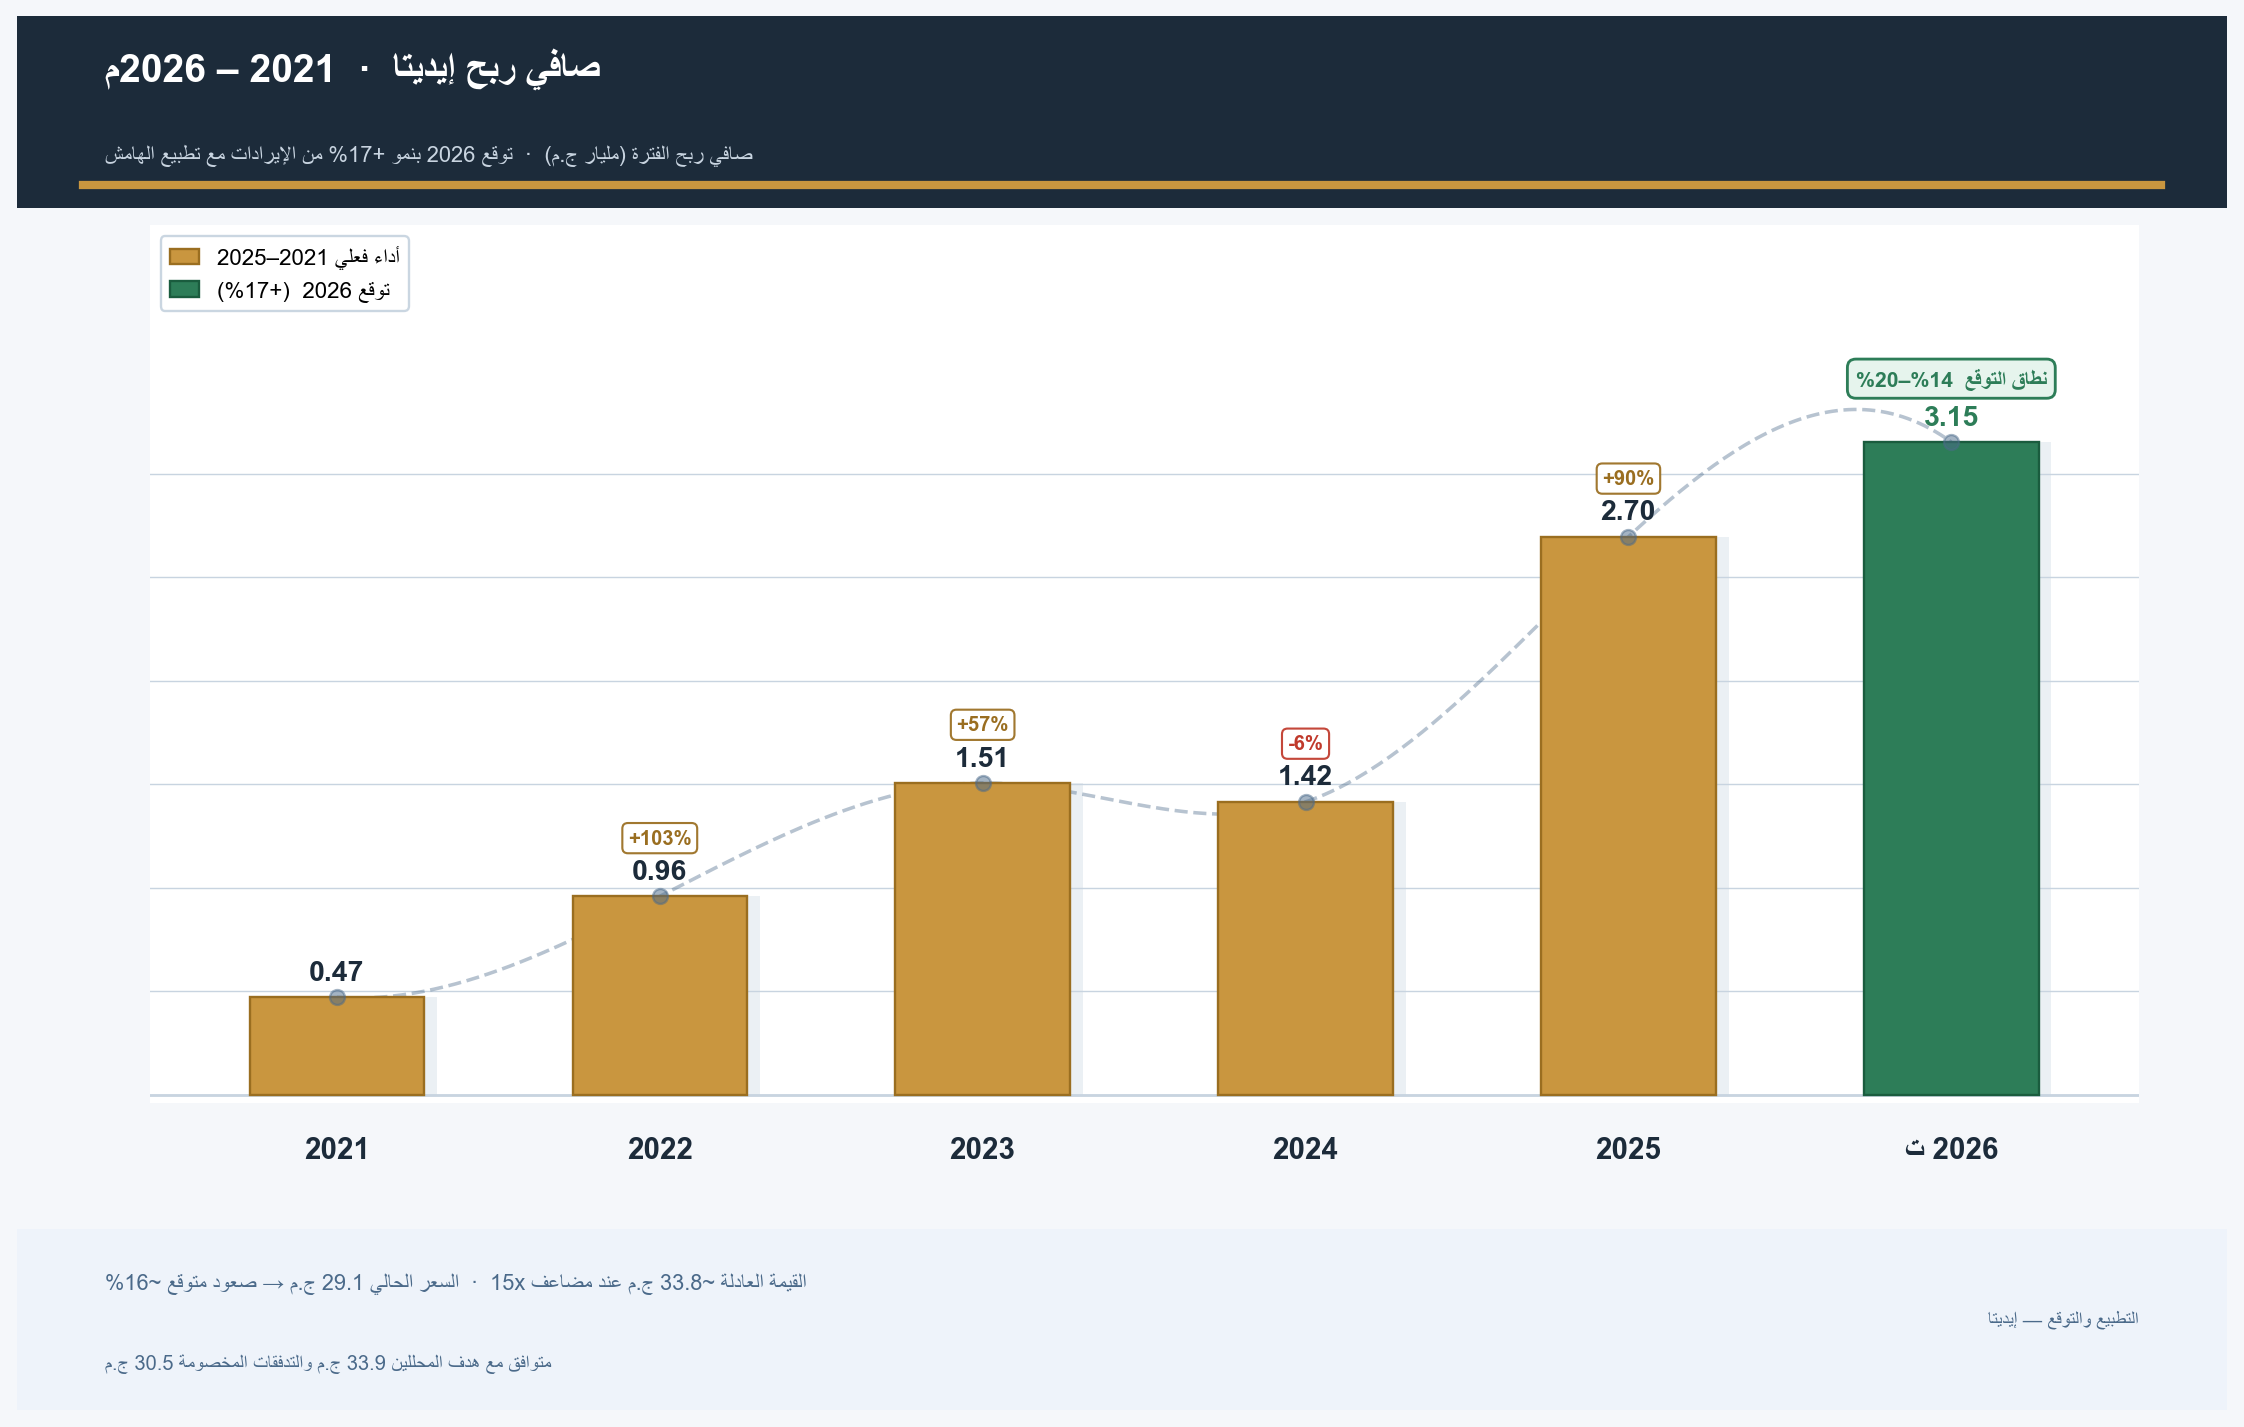

In [50]:
# -*- coding: utf-8 -*-
"""صافي ربح الفترة لإيديتا 2021-2025 + توقّع 2026 — تصميم احترافي محسّن"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

# ── ألوان
BG    = "#F5F7FA"; INK   = "#1C2B3A"; GOLD  = "#C9963F"
GOLDE = "#9A6E20"; SAGE  = "#2D7D58"; SAGEE = "#1A5C3E"
STEEL = "#4B6A8A"; MIST  = "#C8D4E0"; LBLUE = "#EEF3FA"
RED   = "#C0392B"

# ── خط
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = c; break
plt.rcParams["axes.unicode_minus"] = False

# ── بيانات
years  = ["2021","2022","2023","2024","2025","2026 ت"]
x      = np.arange(6)
net    = [471.9, 959.4, 1506.6, 1415.4, 2695.3, 3153.0]
lo, hi = 3072.6, 3234.4
growth = [None] + [round((net[i]-net[i-1])/net[i-1]*100) for i in range(1,6)]

# ── هيكل الشكل
fig = plt.figure(figsize=(13, 8.2), dpi=170)
fig.patch.set_facecolor(BG)

# الترويسة الداكنة
hax = fig.add_axes([0, 0.862, 1, 0.138])
hax.set_facecolor(INK)
for sp in hax.spines.values(): sp.set_visible(False)
hax.set_xticks([]); hax.set_yticks([])
hax.axhline(0.12, xmin=0.03, xmax=0.97, color=GOLD, lw=3.5)
hax.text(0.04, 0.73, ar("صافي ربح إيديتا  ·  2021 – 2026م"),
         transform=hax.transAxes, fontsize=16.5, color="white", weight="bold", va="center")
hax.text(0.04, 0.28, ar("صافي ربح الفترة (مليار ج.م)  ·  توقّع 2026 بنمو +17% من الإيرادات مع تطبيع الهامش"),
         transform=hax.transAxes, fontsize=9.3, color=MIST, va="center")

# التذييل  ← نهايته 0.13
fax = fig.add_axes([0, 0, 1, 0.13])
fax.set_facecolor(LBLUE)
for sp in fax.spines.values(): sp.set_visible(False)
fax.set_xticks([]); fax.set_yticks([])
fax.text(0.04, 0.70, ar("القيمة العادلة ~33.8 ج.م عند مضاعف 15x  ·  السعر الحالي 29.1 ج.م → صعود متوقّع ~16%"),
         transform=fax.transAxes, fontsize=9.2, color=STEEL, va="center")
fax.text(0.04, 0.26, ar("متوافق مع هدف المحللين 33.9 ج.م والتدفقات المخصومة 30.5 ج.م"),
         transform=fax.transAxes, fontsize=8.5, color=STEEL, va="center")
fax.text(0.96, 0.50, ar("التطبيع والتوقّع — إيديتا"),
         transform=fax.transAxes, fontsize=8.2, color=STEEL, va="center", ha="right")

# محور الرسم ← يبدأ من 0.22 ليترك مساحة للسنين فوق التذييل
ax = fig.add_axes([0.06, 0.22, 0.90, 0.63])
ax.set_facecolor("white")
for sp in ax.spines.values(): sp.set_visible(False)

# ── شبكة خفيفة
for yv in [500, 1000, 1500, 2000, 2500, 3000]:
    ax.axhline(yv, color=MIST, lw=0.6, zorder=1)

# ── الأعمدة مع ظل (بدون هاشتش)
bw = 0.54
for i, (xi, v) in enumerate(zip(x, net)):
    clr = SAGE if i == 5 else GOLD
    ecl = SAGEE if i == 5 else GOLDE
    ax.bar(xi + 0.04, v, bw, color=MIST, alpha=0.35, zorder=2)
    ax.bar(xi, v, bw, color=clr, edgecolor=ecl, lw=1.0, zorder=3)

# ── خط الاتجاه
try:
    from scipy.interpolate import make_interp_spline
    xs = np.linspace(0, 5, 300); ys = make_interp_spline(x, net, k=3)(xs)
except ImportError:
    xs = np.linspace(0, 5, 300); ys = np.polyval(np.polyfit(x, net, 3), xs)
ax.plot(xs, ys, color=STEEL, lw=1.5, ls="--", alpha=0.4, zorder=2)
ax.scatter(x, net, color=STEEL, s=40, zorder=5, alpha=0.5)

# ── نطاق التوقع
ax.text(5, hi + 190, ar("نطاق التوقّع  14%–20%"),
        ha="center", fontsize=9, color=SAGE, weight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#E6F4ED", ec=SAGE, lw=1.2))

# ── تسميات القيم + شارات النمو
for xi, v, g in zip(x, net, growth):
    ax.text(xi, v + 55, f"{v/1000:.2f}",
            ha="center", va="bottom", fontsize=12, weight="bold",
            color=SAGE if xi==5 else INK, zorder=8)
    if g is not None and xi != 5:
        gc = RED if g < 0 else GOLDE
        ax.text(xi, v + 235, f"{'+'if g>0 else ''}{g}%",
                ha="center", va="bottom", fontsize=8.5, weight="bold",
                color=gc, zorder=8,
                bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=gc, lw=0.9, alpha=0.93))

# ── وسيلة الإيضاح
leg = [mpatches.Patch(facecolor=GOLD, edgecolor=GOLDE, label=ar("أداء فعلي 2021–2025")),
       mpatches.Patch(facecolor=SAGE, edgecolor=SAGEE, label=ar("توقّع 2026  (+17%)"))]
ax.legend(handles=leg, loc="upper left", fontsize=9.5,
          framealpha=0.95, edgecolor=MIST, facecolor="white", handlelength=1.3)

# ── السنين تحت ← pad=14
ax.set_xticks(x)
ax.set_xticklabels([ar(y) if "ت" in y else y for y in years],
                   fontsize=12.5, color=INK, weight="bold")
ax.tick_params(axis="x", length=0, pad=14)
ax.set_yticks([]); ax.set_xlim(-0.58, 5.58); ax.set_ylim(-40, 4200)
ax.axhline(0, color=MIST, lw=1.2)

plt.savefig("edita_forecast_2026.png", dpi=170, bbox_inches="tight", facecolor=BG)
plt.savefig("edita_forecast_2026.pdf", bbox_inches="tight", facecolor=BG)
plt.show()


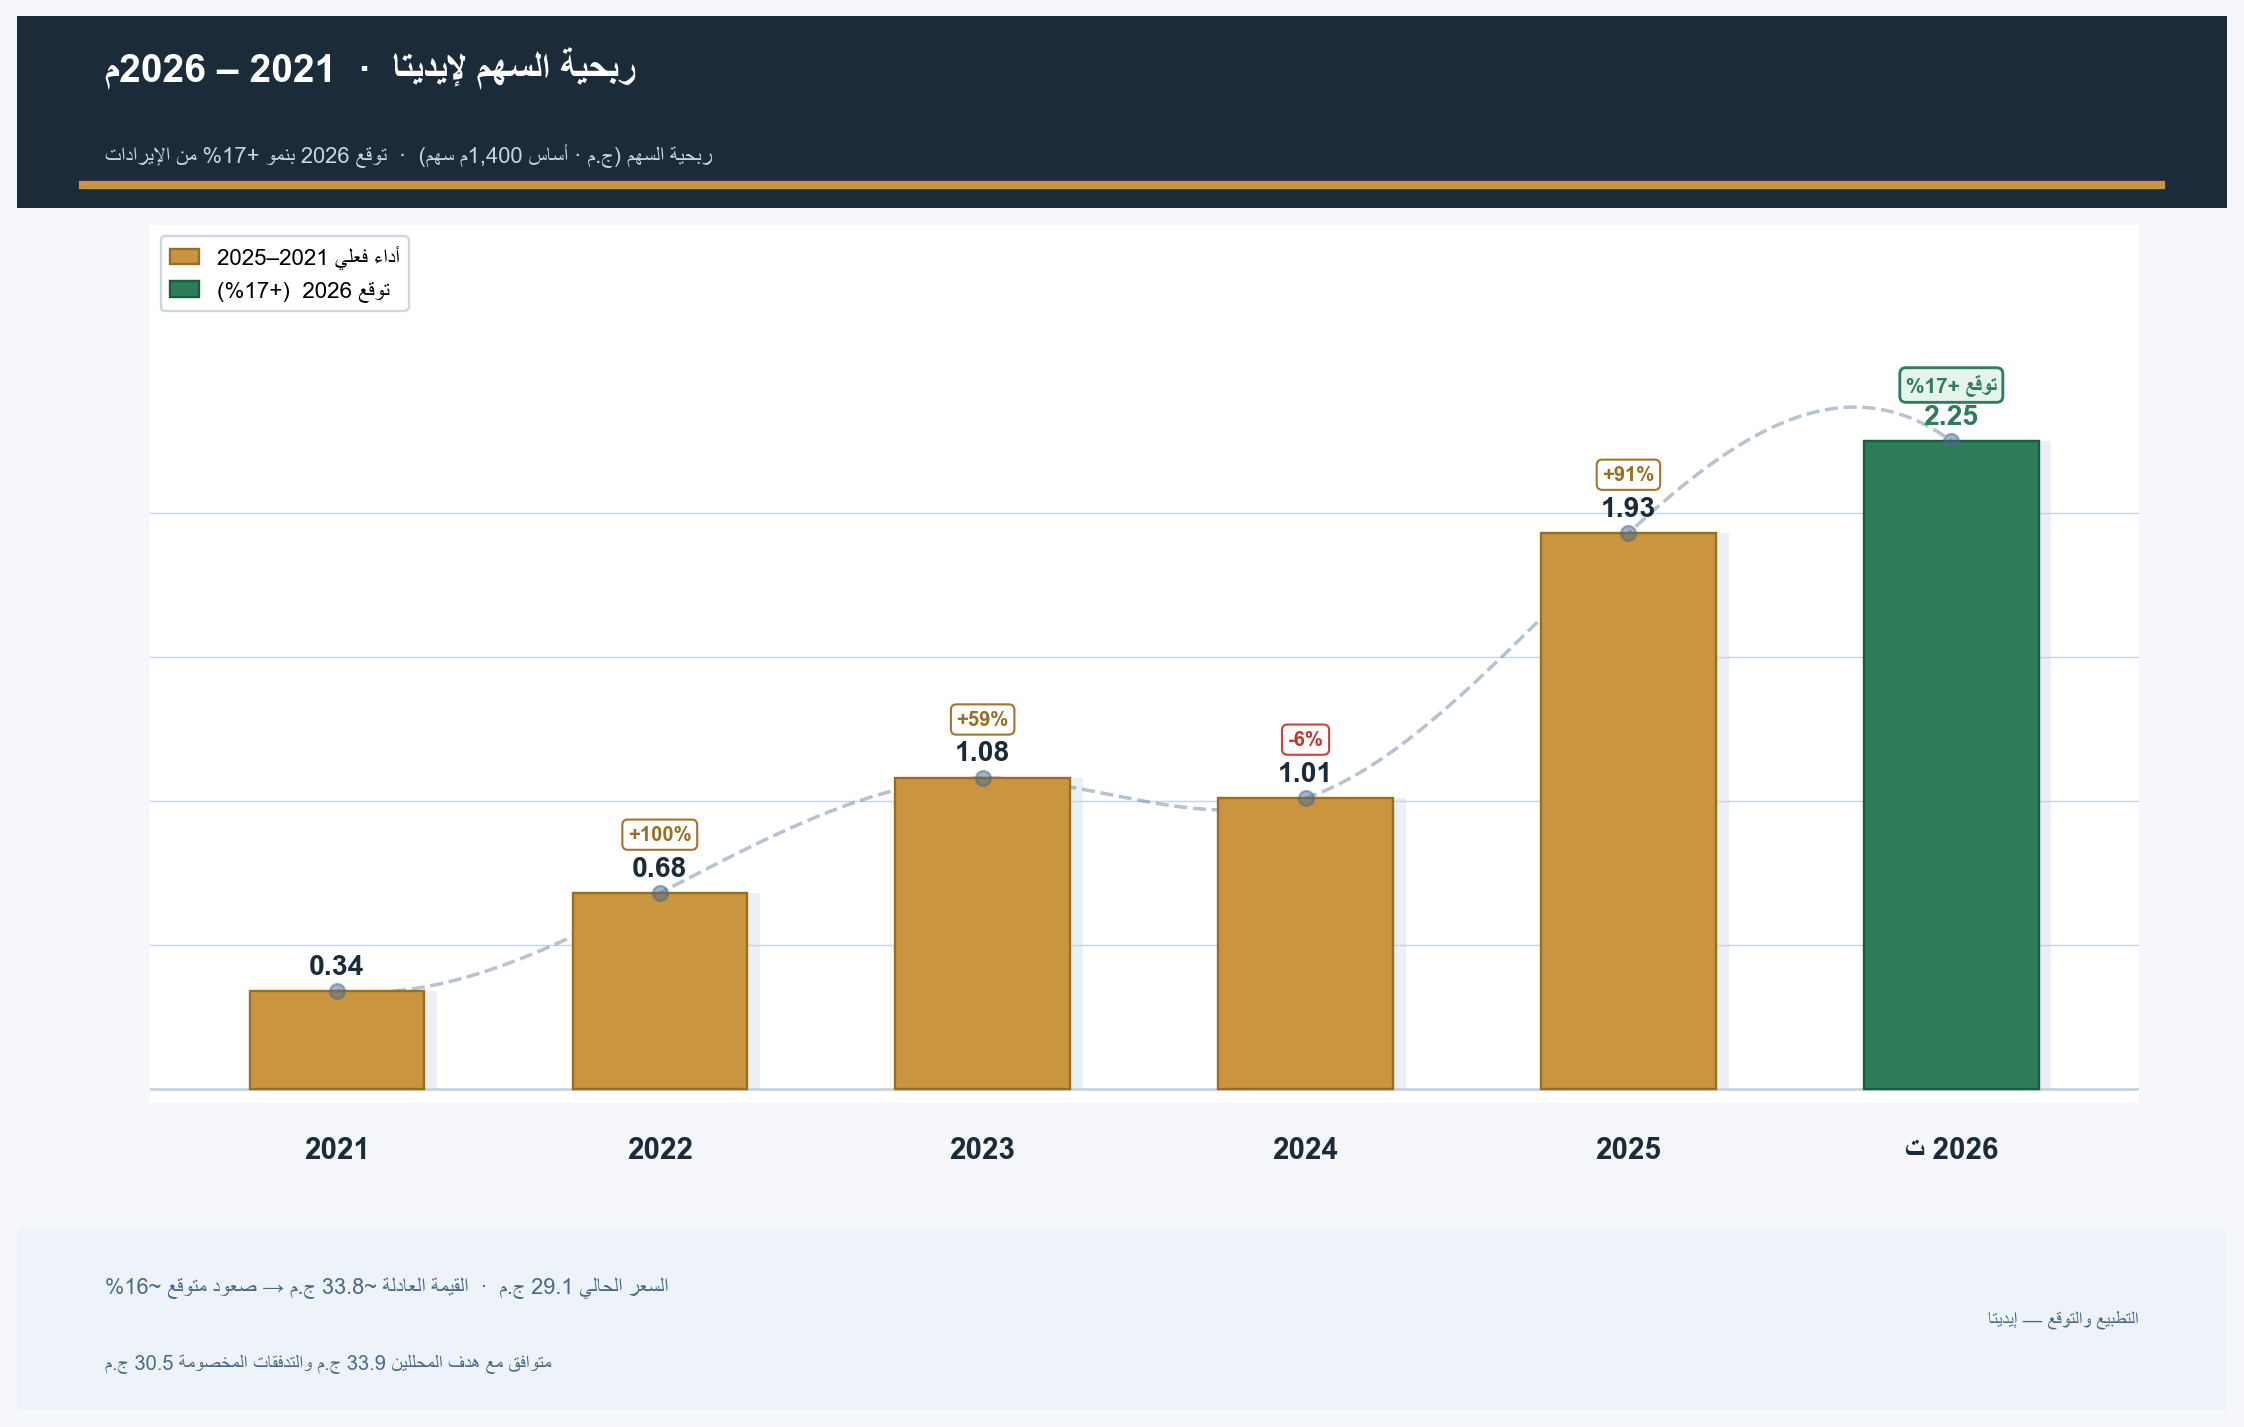

In [47]:
# -*- coding: utf-8 -*-
"""ربحية السهم لإيديتا 2021-2025 + توقّع 2026 — تصميم احترافي"""
import importlib, subprocess, sys
for pkg, mod in [("arabic-reshaper","arabic_reshaper"),("python-bidi","bidi")]:
    try: importlib.import_module(mod)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
import arabic_reshaper
from bidi.algorithm import get_display
def ar(t): return get_display(arabic_reshaper.reshape(str(t)))

import numpy as np, matplotlib.pyplot as plt, matplotlib.font_manager as fm
import matplotlib.patches as mpatches

# ── ألوان
BG    = "#F5F7FA"; INK   = "#1C2B3A"; GOLD  = "#C9963F"
GOLDE = "#9A6E20"; SAGE  = "#2D7D58"; SAGEE = "#1A5C3E"
STEEL = "#4B6A8A"; MIST  = "#C8D4E0"; LBLUE = "#EEF3FA"
RED   = "#C0392B"

# ── خط
for c in ["Cairo","Tajawal","Amiri","Arial","Tahoma","DejaVu Sans"]:
    if any(c.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = c; break
plt.rcParams["axes.unicode_minus"] = False

# ── بيانات
years  = ["2021","2022","2023","2024","2025","2026 ت"]
x      = np.arange(6)
eps    = [0.34, 0.68, 1.08, 1.01, 1.93, 2.25]
growth = [None] + [round((eps[i]-eps[i-1])/eps[i-1]*100) for i in range(1,6)]

# ── هيكل الشكل
fig = plt.figure(figsize=(13, 8.2), dpi=170)
fig.patch.set_facecolor(BG)

# الترويسة الداكنة
hax = fig.add_axes([0, 0.862, 1, 0.138])
hax.set_facecolor(INK)
for sp in hax.spines.values(): sp.set_visible(False)
hax.set_xticks([]); hax.set_yticks([])
hax.axhline(0.12, xmin=0.03, xmax=0.97, color=GOLD, lw=3.5)
hax.text(0.04, 0.73, ar("ربحية السهم لإيديتا  ·  2021 – 2026م"),
         transform=hax.transAxes, fontsize=16.5, color="white", weight="bold", va="center")
hax.text(0.04, 0.28, ar("ربحية السهم (ج.م · أساس 1,400م سهم)  ·  توقّع 2026 بنمو +17% من الإيرادات"),
         transform=hax.transAxes, fontsize=9.3, color=MIST, va="center")

# التذييل  ← نهايته 0.13
fax = fig.add_axes([0, 0, 1, 0.13])
fax.set_facecolor(LBLUE)
for sp in fax.spines.values(): sp.set_visible(False)
fax.set_xticks([]); fax.set_yticks([])
fax.text(0.04, 0.68, ar("السعر الحالي 29.1 ج.م  ·  القيمة العادلة ~33.8 ج.م → صعود متوقّع ~16%"),
         transform=fax.transAxes, fontsize=9.2, color=STEEL, va="center")
fax.text(0.04, 0.26, ar("متوافق مع هدف المحللين 33.9 ج.م والتدفقات المخصومة 30.5 ج.م"),
         transform=fax.transAxes, fontsize=8.5, color=STEEL, va="center")
fax.text(0.96, 0.50, ar("التطبيع والتوقّع — إيديتا"),
         transform=fax.transAxes, fontsize=8.2, color=STEEL, va="center", ha="right")

# محور الرسم ← يبدأ من 0.22 ليترك مساحة كافية للسنين فوق التذييل
ax = fig.add_axes([0.06, 0.22, 0.90, 0.63])
ax.set_facecolor("white")
for sp in ax.spines.values(): sp.set_visible(False)

# ── شبكة خفيفة
for yv in [0.5, 1.0, 1.5, 2.0]:
    ax.axhline(yv, color=MIST, lw=0.6, zorder=1)

# ── الأعمدة مع ظل
bw = 0.54
for i, (xi, v) in enumerate(zip(x, eps)):
    clr = SAGE if i == 5 else GOLD
    ecl = SAGEE if i == 5 else GOLDE
    ax.bar(xi + 0.04, v, bw, color=MIST, alpha=0.35, zorder=2)
    ax.bar(xi, v, bw, color=clr, edgecolor=ecl, lw=1.0, zorder=3)

# ── خط الاتجاه
try:
    from scipy.interpolate import make_interp_spline
    xs = np.linspace(0, 5, 300); ys = make_interp_spline(x, eps, k=3)(xs)
except ImportError:
    xs = np.linspace(0, 5, 300); ys = np.polyval(np.polyfit(x, eps, 3), xs)
ax.plot(xs, ys, color=STEEL, lw=1.5, ls="--", alpha=0.4, zorder=2)
ax.scatter(x, eps, color=STEEL, s=40, zorder=5, alpha=0.5)

# ── تسميات القيم + شارات النمو
for xi, v, g in zip(x, eps, growth):
    ax.text(xi, v + 0.04, f"{v:.2f}",
            ha="center", va="bottom", fontsize=12, weight="bold",
            color=SAGE if xi==5 else INK, zorder=8)
    if g is not None and xi != 5:
        gc = RED if g < 0 else GOLDE
        ax.text(xi, v + 0.17, f"{'+'if g>0 else ''}{g}%",
                ha="center", va="bottom", fontsize=8.5, weight="bold", color=gc, zorder=8,
                bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=gc, lw=0.9, alpha=0.93))

ax.text(5, eps[5] + 0.17, ar("توقّع +17%"),
        ha="center", fontsize=8.8, color=SAGE, weight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="#E6F4ED", ec=SAGE, lw=1.2))

# ── وسيلة الإيضاح
leg = [mpatches.Patch(facecolor=GOLD, edgecolor=GOLDE, label=ar("أداء فعلي 2021–2025")),
       mpatches.Patch(facecolor=SAGE, edgecolor=SAGEE, label=ar("توقّع 2026  (+17%)"))]
ax.legend(handles=leg, loc="upper left", fontsize=9.5,
          framealpha=0.95, edgecolor=MIST, facecolor="white", handlelength=1.3)

# ── السنين تحت ← pad=14 يبعّدها عن الأعمدة بوضوح
ax.set_xticks(x)
ax.set_xticklabels([ar(y) if "ت" in y else y for y in years],
                   fontsize=12.5, color=INK, weight="bold")
ax.tick_params(axis="x", length=0, pad=14)
ax.set_yticks([]); ax.set_xlim(-0.58, 5.58); ax.set_ylim(-0.05, 3.0)
ax.axhline(0, color=MIST, lw=1.2)

plt.savefig("edita_eps_forecast.png", dpi=170, bbox_inches="tight", facecolor=BG)
plt.savefig("edita_eps_forecast.pdf", bbox_inches="tight", facecolor=BG)
plt.show()


 بافتراض نمو صافي ربح +20% (مُشتقّ من نمو الإيراد لا من قفزة الربع الأول المضلِّلة)، يُتوقّع صافي ربح الفترة لإيديتا ~3.23 مليار في 2026، بقيمة عادلة ~34.7 ج.م عند مضاعف 15x — صعود ~19% متوافق مع هدف المحللين ونموذج التدفقات المخصومة.